# Code voor de verwerking en analyse van netheidsindices

# 3.4) Dataverwerking

In [ ]:
# ============================================================
# 0. Packages
# ============================================================

# Eenmalig uitvoeren indien nodig:
# %pip install pandas geopandas fuzzywuzzy python-Levenshtein matplotlib scipy libpysal esda mgwr

import os
import re

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.ticker import FuncFormatter

from fuzzywuzzy import fuzz, process

from scipy.stats import pearsonr, spearmanr

In [37]:
# ============================================================
# 1. Data inladen
# ============================================================

NB_raw = pd.read_excel("20260424_HistoriekNetheidsbarometer_Xander.xlsx")
CCI_raw = pd.read_csv("kibana_all_intervals.csv")

wegen_gdf = gpd.read_file("Wegsegment44021.shp")

NB_raw.head()

,metingID,meetpuntID,Straatnaam,Segment,Datum,Uur,ZW_score,PA_score,SL_score,VA_score,EF_score,TOTAAL
0,33.0,1,KAMMERSTRAAT,van BELFORTSTRAAT tot BIJ SINT-JACOBS,2005-06-01,09:10:00,2.0,20.0,20,20,20,82.0
1,34.0,2,KRAANLEI,van HERTOGSTRAAT tot ZUIVELBRUGSTRAAT,2005-06-01,09:30:00,9.5,0.0,20,20,0,49.5
2,35.0,5,VELDSTRAAT,van VOLDERSTRAAT tot BONTELEEUWSTRAAT,2005-06-01,09:48:00,13.0,20.0,20,20,20,93.0
3,36.0,6,KEIZER KARELSTRAAT,van SINT-ANNAPLEIN tot APOSTELHUIZEN,2005-06-01,09:55:00,14.5,20.0,20,20,0,74.5
4,37.0,9,OVERPOORTSTRAAT,van STALHOF tot VOETWEG,2005-06-01,08:50:00,0.0,20.0,20,10,0,50.0


In [38]:
# ============================================================
# 2. Algemene instellingen en hulpfuncties
# ============================================================

START_DATE = "2024-01-01"
MATCH_THRESHOLD = 95

def normalize_street_name(name):
    """Normaliseer straatnamen voor koppeling."""
    if pd.isna(name):
        return ""

    name = str(name).strip()
    name = re.sub(r"\s+", " ", name)

    # Veelvoorkomende afkortingen
    name = re.sub(r"\bSt\b", "Sint", name, flags=re.IGNORECASE)
    name = re.sub(r"\bStr\b", "Straat", name, flags=re.IGNORECASE)

    return name.strip()

In [39]:
# ============================================================
# 3.4.1 Selectie van observaties (jan 2024 – maart 2026)
# ============================================================

START_DATE = "2024-01-01"
END_DATE   = "2026-03-31"

# -------------------------
# NB
# -------------------------
NB_2024 = NB_raw.copy()
NB_2024["Datum"] = pd.to_datetime(NB_2024["Datum"], errors="coerce")

NB_2024 = NB_2024[
    (NB_2024["Datum"] >= START_DATE) &
    (NB_2024["Datum"] <= END_DATE)
].copy()

# -------------------------
# CCI
# -------------------------
CCI_2024 = CCI_raw.copy()
CCI_2024["date"] = pd.to_datetime(CCI_2024["date"], errors="coerce")

CCI_2024 = CCI_2024[
    (CCI_2024["date"] >= START_DATE) &
    (CCI_2024["date"] <= END_DATE)
].copy()

# -------------------------
# Output
# -------------------------
print(f"Unieke NB-straten (jan 2024 – mrt 2026): {NB_2024['Straatnaam'].dropna().nunique()}")
print(f"Unieke CCI-straten (jan 2024 – mrt 2026): {CCI_2024['Street'].dropna().nunique()}")

Unieke NB-straten (jan 2024 – mrt 2026): 62
Unieke CCI-straten (jan 2024 – mrt 2026): 2399


In [40]:
# ============================================================
# 3.4.2 Koppeling van straatnamen
# ============================================================

unique_nb = pd.Series(NB_2024["Straatnaam"].dropna().astype(str).unique())
unique_cci = pd.Series(CCI_2024["Street"].dropna().astype(str).unique())

nb_norm_map = {name: normalize_street_name(name) for name in unique_nb}
cci_norm_map = {name: normalize_street_name(name) for name in unique_cci}

# ------------------------------------------------------------
# Stap 1: gelijkaardige NB-straatnamen groeperen
# ------------------------------------------------------------

nb_groups = {}

for nb_name in unique_nb:
    nb_norm = nb_norm_map[nb_name]

    if not nb_groups:
        nb_groups[nb_name] = [nb_name]
        continue

    canon_candidates = list(nb_groups.keys())
    canon_norms = [nb_norm_map[c] for c in canon_candidates]

    best_match = process.extractOne(
        nb_norm,
        canon_norms,
        scorer=fuzz.token_sort_ratio
    )

    if best_match is not None:
        best_norm_match, score = best_match

        if score >= MATCH_THRESHOLD:
            matched_canon = canon_candidates[canon_norms.index(best_norm_match)]
            nb_groups[matched_canon].append(nb_name)
        else:
            nb_groups[nb_name] = [nb_name]
    else:
        nb_groups[nb_name] = [nb_name]

# ------------------------------------------------------------
# Stap 2: elke NB-groep krijgt een unieke key
# ------------------------------------------------------------

canon_to_key = {}
nb_to_key = {}
key_counter = 0

for canon_name, variants in nb_groups.items():
    canon_to_key[canon_name] = key_counter

    for variant in variants:
        nb_to_key[variant] = key_counter

    key_counter += 1

# ------------------------------------------------------------
# Stap 3: CCI-straten koppelen aan NB-groepen
# ------------------------------------------------------------

rows = []

canon_names = list(nb_groups.keys())
canon_norm_map = {canon: normalize_street_name(canon) for canon in canon_names}
canon_norms = [canon_norm_map[c] for c in canon_names]

for cci_name in unique_cci:
    cci_norm = cci_norm_map[cci_name]

    best_match = process.extractOne(
        cci_norm,
        canon_norms,
        scorer=fuzz.token_sort_ratio
    )

    if best_match is not None:
        best_norm_match, score = best_match

        if score >= MATCH_THRESHOLD:
            matched_canon = canon_names[canon_norms.index(best_norm_match)]
            key = canon_to_key[matched_canon]

            rows.append({
                "CCI_straten": cci_name,
                "key": int(key),
                "NB_straten": matched_canon
            })

        else:
            rows.append({
                "CCI_straten": cci_name,
                "key": int(key_counter),
                "NB_straten": None
            })
            key_counter += 1

# ------------------------------------------------------------
# Stap 4: NB-only straten toevoegen
# ------------------------------------------------------------

matched_nb_names = set(
    row["NB_straten"] for row in rows if pd.notna(row["NB_straten"])
)

nb_only_rows = []

for canon_name, variants in nb_groups.items():
    key = canon_to_key[canon_name]

    if canon_name not in matched_nb_names:
        for variant in variants:
            nb_only_rows.append({
                "CCI_straten": None,
                "key": int(key),
                "NB_straten": variant
            })
    else:
        for variant in variants:
            if variant != canon_name:
                nb_only_rows.append({
                    "CCI_straten": None,
                    "key": int(key),
                    "NB_straten": variant
                })

matched_index = pd.DataFrame(rows + nb_only_rows)

matched_index = matched_index.sort_values(
    ["key", "CCI_straten", "NB_straten"],
    na_position="last"
).reset_index(drop=True)

matched_index.to_csv("matched_index.csv", index=False)

n_matched = matched_index.loc[
    matched_index[["CCI_straten", "NB_straten"]].notna().all(axis=1),
    "key"
].nunique()

print(f"Aantal gekoppelde NB-CCI straten: {n_matched}")

Aantal gekoppelde NB-CCI straten: 62


In [41]:
# ============================================================
# 3.4.2 Koppeling met geometrieën
# ============================================================

wegen_gdf = wegen_gdf.copy()

name_col = "LSTRNM"

wegen_gdf["naam_normalized"] = (
    wegen_gdf[name_col]
    .fillna("")
    .astype(str)
    .apply(normalize_street_name)
    .str.strip()
    .str.upper()
)

wegen_gdf = wegen_gdf[wegen_gdf["naam_normalized"] != ""].copy()

# Alle wegsegmenten met dezelfde straatnaam samenvoegen
gdf_streets = wegen_gdf.dissolve(by="naam_normalized").reset_index()

name_to_geometry = dict(
    zip(gdf_streets["naam_normalized"], gdf_streets["geometry"])
)

def get_geometry_fuzzy_with_type(cci_name, nb_name=None):
    """Zoekt geometrie via exacte match, daarna fuzzy match."""

    if pd.notna(cci_name) and str(cci_name).strip():
        name_to_check = cci_name
    elif pd.notna(nb_name) and str(nb_name).strip():
        name_to_check = nb_name
    else:
        return None, "none"

    norm_name = normalize_street_name(name_to_check).strip().upper()

    if norm_name in name_to_geometry:
        return name_to_geometry[norm_name], "exact"

    matches = process.extract(
        norm_name,
        list(name_to_geometry.keys()),
        scorer=fuzz.token_sort_ratio,
        limit=1
    )

    if matches and matches[0][1] >= MATCH_THRESHOLD:
        return name_to_geometry[matches[0][0]], "fuzzy"

    return None, "none"

def get_occurrence(nb_name, cci_name):
    nb_exists = pd.notna(nb_name) and str(nb_name).strip() != ""
    cci_exists = pd.notna(cci_name) and str(cci_name).strip() != ""

    if nb_exists and cci_exists:
        return "both"
    elif nb_exists:
        return "NB"
    elif cci_exists:
        return "CCI"
    else:
        return None

matched_index["occurrence"] = matched_index.apply(
    lambda row: get_occurrence(row["NB_straten"], row["CCI_straten"]),
    axis=1
)

geometry_results = matched_index.apply(
    lambda row: get_geometry_fuzzy_with_type(row["CCI_straten"], row["NB_straten"]),
    axis=1
)

matched_index["geometry"] = geometry_results.apply(lambda x: x[0])
match_types = geometry_results.apply(lambda x: x[1])

matched_index_gdf = gpd.GeoDataFrame(
    matched_index,
    geometry="geometry",
    crs=wegen_gdf.crs
)

matched_index_gdf.to_file("matched_index_with_geometry.shp")

# Controle-output
exact_count = (match_types == "exact").sum()
fuzzy_count = (match_types == "fuzzy").sum()
none_count = (match_types == "none").sum()
total_rows = len(matched_index_gdf)

street_level = matched_index_gdf.groupby("key").agg(
    has_geometry=("geometry", lambda x: x.notna().any())
).reset_index()

matched_streets = street_level["has_geometry"].sum()
total_streets = len(street_level)

print(f"Straten met geometrie: {matched_streets} / {total_streets}")
print(f"Exacte matches: {exact_count}")
print(f"Fuzzy matches: {fuzzy_count}")
print(f"Geen match: {none_count}")

C:\Users\luyck\AppData\Local\Temp\ipykernel_51400\2223886740.py:86: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  matched_index_gdf.to_file("matched_index_with_geometry.shp")
C:\Users\luyck\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'CCI_straten' to 'CCI_strate'
  ogr_write(


Straten met geometrie: 2355 / 2398
Exacte matches: 2355
Fuzzy matches: 1
Geen match: 43


In [42]:
# ============================================================
# 3.4.3 Standaardisatie NB_clean
# ============================================================

NB_clean = NB_raw.copy()

NB_clean["Datum"] = pd.to_datetime(NB_clean["Datum"], errors="coerce")
NB_clean = NB_clean[NB_clean["Datum"] >= START_DATE].copy()

score_cols_20 = ["ZW_score", "PA_score", "SL_score", "VA_score", "EF_score"]

for col in score_cols_20:
    NB_clean[f"{col}_std"] = NB_clean[col] / 20.0

NB_clean["TOTAAL_std"] = NB_clean["TOTAAL"] / 100.0

# Uurveld standaardiseren naar HH:MM
orig_uur = NB_clean["Uur"]
parsed_uur = pd.to_datetime(orig_uur, errors="coerce").dt.strftime("%H:%M")
NB_clean["Uur"] = parsed_uur.fillna(orig_uur.astype(str).str[:5])

# Datum en uur samenvoegen tot één tijdstempel
NB_clean["nb_ts"] = pd.to_datetime(
    NB_clean["Datum"].dt.strftime("%Y-%m-%d") + " " + NB_clean["Uur"].astype(str),
    errors="coerce"
)

street_key_map_nb = dict(zip(matched_index["NB_straten"], matched_index["key"]))
NB_clean["key"] = NB_clean["Straatnaam"].map(street_key_map_nb).astype("Int64")

NB_clean = NB_clean.rename(columns={
    "Straatnaam": "NB_straten",
    "Datum": "datum",
    "Uur": "uur"
})

NB_clean = NB_clean[
    [
        "NB_straten",
        "key",
        "datum",
        "uur",
        "nb_ts",
        "ZW_score_std",
        "PA_score_std",
        "SL_score_std",
        "VA_score_std",
        "EF_score_std",
        "TOTAAL_std"
    ]
]

NB_clean.head()

,NB_straten,key,datum,uur,nb_ts,ZW_score_std,PA_score_std,SL_score_std,VA_score_std,EF_score_std,TOTAAL_std
14460,RECHTSTRAAT,0,2024-01-23,09:27,2024-01-23 09:27:00,0.850,1.0,1.00,1.00,1.00,0.970
14461,GENTSTRAAT,1,2024-01-23,09:51,2024-01-23 09:51:00,0.825,1.0,1.00,0.75,1.00,0.915
14462,SINT-BERNADETTESTRAAT,2,2024-01-23,10:07,2024-01-23 10:07:00,0.850,1.0,1.00,1.00,0.50,0.870
14463,SCHOOLSTRAAT,3,2024-01-23,10:22,2024-01-23 10:22:00,0.650,0.5,0.25,0.00,0.50,0.380
14464,HEILIG-HARTSTRAAT,4,2024-01-23,10:42,2024-01-23 10:42:00,0.675,1.0,0.75,1.00,0.75,0.835


In [43]:
# ============================================================
# 3.4.3 Standaardisatie CCI_clean
# ============================================================

CCI_clean = CCI_raw.copy()

CCI_clean["date"] = pd.to_datetime(CCI_clean["date"], errors="coerce")
CCI_clean = CCI_clean[CCI_clean["date"] >= START_DATE].copy()

CCI_clean["AverageCCI_std"] = CCI_clean["AverageCCI"] / 5.0

street_key_map_cci = dict(zip(matched_index["CCI_straten"], matched_index["key"]))
CCI_clean["key"] = CCI_clean["Street"].map(street_key_map_cci).astype("Int64")

# Tijdveldena standaardiseren
CCI_clean["start_time"] = CCI_clean["start_time"].astype(str).str[:5]
CCI_clean["end_time"] = CCI_clean["end_time"].astype(str).str[:5]

# Datum + tijd samenvoegen tot tijdstempels
CCI_clean["start_ts"] = pd.to_datetime(
    CCI_clean["date"].dt.strftime("%Y-%m-%d") + " " + CCI_clean["start_time"],
    errors="coerce"
)

CCI_clean["end_ts"] = pd.to_datetime(
    CCI_clean["date"].dt.strftime("%Y-%m-%d") + " " + CCI_clean["end_time"],
    errors="coerce"
)

CCI_clean = CCI_clean.rename(columns={
    "Street": "CCI_straten",
    "date": "datum",
    "start_time": "start_uur",
    "end_time": "eind_uur",
    "Snapshot Count": "snapshots"
})

CCI_clean = CCI_clean[
    [
        "CCI_straten",
        "key",
        "datum",
        "start_uur",
        "eind_uur",
        "start_ts",
        "end_ts",
        "AverageCCI_std",
        "snapshots"
    ]
]

CCI_clean.head()

,CCI_straten,key,datum,start_uur,eind_uur,start_ts,end_ts,AverageCCI_std,snapshots
0,'t Stuk,62,2024-12-14,13:15,13:30,2024-12-14 13:15:00,2024-12-14 13:30:00,0.92,2
1,'t Stuk,62,2024-12-14,16:15,16:30,2024-12-14 16:15:00,2024-12-14 16:30:00,1.00,2
2,'t Stuk,62,2024-12-25,14:00,14:15,2024-12-25 14:00:00,2024-12-25 14:15:00,0.92,2
3,'t Stuk,62,2024-12-25,15:30,15:45,2024-12-25 15:30:00,2024-12-25 15:45:00,1.00,2
4,'t Stuk,62,2025-01-08,12:00,12:15,2025-01-08 12:00:00,2025-01-08 12:15:00,1.00,3


# 3.5)  Studiegebied

In [44]:
# ============================================================
# 3.5 Afbakening studiegebied
# ============================================================

wegen_relevant = wegen_gdf.copy()

wegen_relevant["LBLMORF_norm"] = (
    wegen_relevant["LBLMORF"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

exclude_morf = ["aardeweg", "autosnelweg", "veer"]

# Totaal aantal unieke straten vóór filtering
gdf_all_streets = wegen_relevant.dissolve(by="naam_normalized").reset_index()
total_unique_all_streets = gdf_all_streets["naam_normalized"].nunique()

# Niet-relevante morfologische types uitsluiten
gdf_relevant = wegen_relevant[
    ~wegen_relevant["LBLMORF_norm"].isin(exclude_morf)
].copy()

gdf_relevant_streets = gdf_relevant.dissolve(by="naam_normalized").reset_index()
total_unique_relevant_streets = gdf_relevant_streets["naam_normalized"].nunique()

excluded = total_unique_all_streets - total_unique_relevant_streets
excluded_pct = excluded / total_unique_all_streets

print(f"Totaal aantal unieke straten: {total_unique_all_streets}")
print(f"Totaal aantal relevante straten: {total_unique_relevant_streets}")
print(f"Uitgesloten straten: {excluded} ({excluded_pct:.2%})")

# Ruimtelijke dekking
n_cci = CCI_clean["CCI_straten"].dropna().nunique()
n_nb = NB_clean["NB_straten"].dropna().nunique()

cci_coverage = n_cci / total_unique_relevant_streets
nb_coverage = n_nb / total_unique_relevant_streets

print(f"CCI-dekking = {n_cci} / {total_unique_relevant_streets} = {cci_coverage:.2%}")
print(f"NB-dekking  = {n_nb} / {total_unique_relevant_streets} = {nb_coverage:.2%}")

rest = total_unique_relevant_streets - n_cci
rest_percentage = rest / total_unique_relevant_streets

print(f"Niet gemeten door CCI = {rest} / {total_unique_relevant_streets} = {rest_percentage:.2%}")

Totaal aantal unieke straten: 3091
Totaal aantal relevante straten: 3079
Uitgesloten straten: 12 (0.39%)
CCI-dekking = 2416 / 3079 = 78.47%
NB-dekking  = 62 / 3079 = 2.01%
Niet gemeten door CCI = 663 / 3079 = 21.53%


In [45]:
# ============================================================
# Extra: CCI straatniveau-export voor ruimtelijke analyse
# ============================================================

CCI_daily = (
    CCI_clean
    .groupby(["CCI_straten", "key", "datum"], as_index=False)
    .agg({
        "AverageCCI_std": "mean"
    })
)

CCI_street_summary = (
    CCI_daily
    .groupby(["CCI_straten", "key"], as_index=False)
    .agg({
        "AverageCCI_std": "mean",
        "datum": "nunique"
    })
    .rename(columns={
        "datum": "n_observations"
    })
)

CCI_street_gdf = matched_index_gdf.merge(
    CCI_street_summary,
    on=["CCI_straten", "key"],
    how="left"
)

CCI_street_gdf = CCI_street_gdf[
    CCI_street_gdf["n_observations"].notna()
].copy()

CCI_street_gdf["n_observations"] = CCI_street_gdf["n_observations"].astype(int)

CCI_street_gdf.to_file("CCI_street_summary.shp", driver="ESRI Shapefile")

print(f"Aantal CCI-straten in shapefile: {len(CCI_street_gdf)}")
CCI_street_gdf.head()

Aantal CCI-straten in shapefile: 2399


C:\Users\luyck\AppData\Local\Temp\ipykernel_51400\3160814498.py:37: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  CCI_street_gdf.to_file("CCI_street_summary.shp", driver="ESRI Shapefile")
C:\Users\luyck\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'CCI_straten' to 'CCI_strate'
  ogr_write(
C:\Users\luyck\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'AverageCCI_std' to 'AverageCCI'
  ogr_write(
C:\Users\luyck\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'n_observations' to 'n_observat'
  ogr_writ

,CCI_straten,key,NB_straten,occurrence,geometry,AverageCCI_std,n_observations
0,Rechtstraat,0,RECHTSTRAAT,both,"MULTILINESTRING ((109446.664 201434.454, 10946...",0.907400,5
1,Gentstraat,1,GENTSTRAAT,both,"MULTILINESTRING ((107416.291 198651.546, 10741...",0.947262,28
2,Sint-Bernadettestraat,2,SINT-BERNADETTESTRAAT,both,"MULTILINESTRING ((106978.5 196297.496, 106979....",0.926846,26
3,Schoolstraat,3,SCHOOLSTRAAT,both,"MULTILINESTRING ((106496.1 194634.696, 106527....",0.914222,27
4,Heilig-Hartstraat,4,HEILIG-HARTSTRAAT,both,"MULTILINESTRING ((106548.438 193927.454, 10654...",0.869765,36


# 3.6) Exploratieve analyse

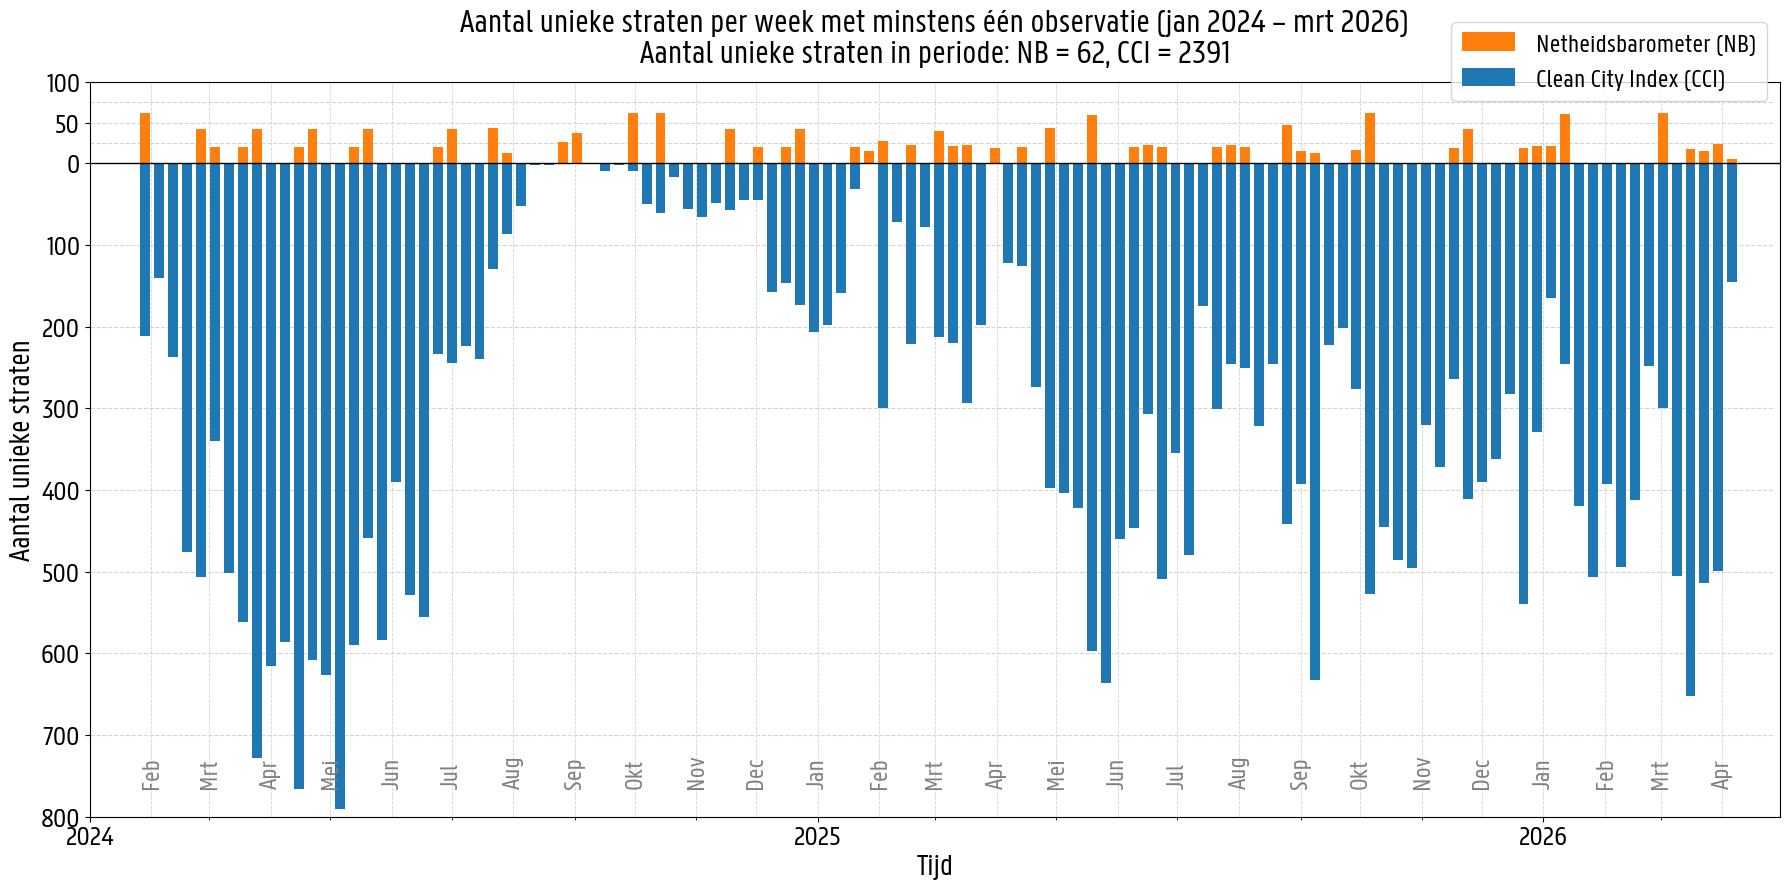

         time  NB_unieke_straten  CCI_unieke_straten
0  2024-01-01                0.0                 0.0
1  2024-01-08                0.0                 0.0
2  2024-01-15                0.0                 0.0
3  2024-01-22                0.0                 0.0
4  2024-01-29               62.0               211.0
5  2024-02-05                0.0               140.0
6  2024-02-12                0.0               237.0
7  2024-02-19                0.0               476.0
8  2024-02-26               42.0               506.0
9  2024-03-04               20.0               340.0
10 2024-03-11                0.0               501.0
11 2024-03-18               20.0               562.0


In [ ]:
# =========================
# 1. Data voorbereiden
# =========================
CCI = CCI_clean.copy()
NB = NB_clean.copy()

CCI["datum"] = pd.to_datetime(CCI["datum"], errors="coerce")
NB["datum"] = pd.to_datetime(NB["datum"], errors="coerce")

CCI["Street_clean"] = CCI["CCI_straten"].astype(str).str.strip().str.upper()
NB["Straatnaam_clean"] = NB["NB_straten"].astype(str).str.strip().str.upper()

# =========================
# 2. Periode instellen
# =========================
start_date = "2024-01-01"
end_date   = "2026-03-31"

CCI = CCI[(CCI["datum"] >= start_date) & (CCI["datum"] <= end_date)].copy()
NB = NB[(NB["datum"] >= start_date) & (NB["datum"] <= end_date)].copy()

# =========================
# 3. Functie
# =========================
def plot_mirrored_unique_streets_weekly(
    CCI_df,
    NB_df,
    start_date="2024-01-01",
    end_date="2026-03-31",
    freq="W-MON",
    nb_max=100,
    cci_max=800,
    save_path=None
):
    nb_total_unique = NB_df["Straatnaam_clean"].dropna().nunique()
    cci_total_unique = CCI_df["Street_clean"].dropna().nunique()

    nb_counts = (
        NB_df.dropna(subset=["datum", "Straatnaam_clean"])
             .groupby(pd.Grouper(key="datum", freq=freq))["Straatnaam_clean"]
             .nunique()
             .reset_index(name="NB_unieke_straten")
             .rename(columns={"datum": "time"})
    )

    cci_counts = (
        CCI_df.dropna(subset=["datum", "Street_clean"])
              .groupby(pd.Grouper(key="datum", freq=freq))["Street_clean"]
              .nunique()
              .reset_index(name="CCI_unieke_straten")
              .rename(columns={"datum": "time"})
    )

    full_time_index = pd.date_range(start=start_date, end=end_date, freq=freq)

    timeline = pd.DataFrame({"time": full_time_index})
    timeline = timeline.merge(nb_counts, on="time", how="left")
    timeline = timeline.merge(cci_counts, on="time", how="left")

    timeline["NB_unieke_straten"] = timeline["NB_unieke_straten"].fillna(0)
    timeline["CCI_unieke_straten"] = timeline["CCI_unieke_straten"].fillna(0)

    # =========================
    # FIGUUR
    # =========================
    fig, ax = plt.subplots(figsize=(18, 9))

    width_days = 5

    ax.bar(
        timeline["time"],
        timeline["NB_unieke_straten"],
        width=width_days,
        align="center",
        color="C1",
        label="Netheidsbarometer (NB)"
    )

    ax.bar(
        timeline["time"],
        -timeline["CCI_unieke_straten"],
        width=width_days,
        align="center",
        color="C0",
        label="Clean City Index (CCI)"
    )

    ax.axhline(0, color="black", linewidth=1)

    # =========================
    # Hulplijnen NB
    # =========================
    nb_guides = [25, 50, 75, 100]
    for y in nb_guides:
        if y <= nb_max:
            ax.hlines(
                y=y,
                xmin=timeline["time"].min(),
                xmax=timeline["time"].max(),
                colors="lightgray",
                linestyles="dashed",
                linewidth=0.8,
                zorder=0
            )

    # =========================
    # Hulplijnen CCI
    # =========================
    cci_guides = [100, 200, 300, 400, 500, 600, 700, 800]
    for y in cci_guides:
        if y <= cci_max:
            ax.hlines(
                y=-y,
                xmin=timeline["time"].min(),
                xmax=timeline["time"].max(),
                colors="lightgray",
                linestyles="dashed",
                linewidth=0.8,
                zorder=0
            )

    ax.set_ylim(-cci_max, nb_max)

    # =========================
    # Y-as labels
    # =========================
    nb_ticks = [0, 50, 100]
    cci_ticks = [-100, -200, -300, -400, -500, -600, -700, -800]

    yticks = cci_ticks + nb_ticks
    yticklabels = [
        "100", "200", "300", "400", "500", "600", "700", "800",
        "0", "50", "100"
    ]

    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels, fontsize=20)

    # =========================
    # TITEL
    # =========================
    ax.set_title(
        f"Aantal unieke straten per week met minstens één observatie (jan 2024 – mrt 2026)\n"
        f"Aantal unieke straten in periode: NB = {nb_total_unique}, CCI = {cci_total_unique}",
        fontsize=24,
        fontweight="bold",
        pad=14
    )

    # =========================
    # ASSENLABELS
    # =========================
    ax.set_xlabel("Tijd", fontsize=22, fontweight="bold")
    ax.set_ylabel("Aantal unieke straten", fontsize=22, fontweight="bold")

    # =========================
    # X-as
    # =========================
    ax.set_xlim(pd.to_datetime(start_date), pd.to_datetime(end_date))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=2))

    # =========================
    # Verticale maandlijnen
    # =========================
    month_starts = pd.date_range(start=start_date, end=end_date, freq="MS")

    for date in month_starts:
        ax.axvline(
            x=date,
            color="lightgray",
            linestyle="dashed",
            linewidth=0.6,
            zorder=0
        )

    # =========================
    # Nederlandse maandlabels
    # =========================
    maanden_nl = {
        1: "Jan", 2: "Feb", 3: "Mrt", 4: "Apr",
        5: "Mei", 6: "Jun", 7: "Jul", 8: "Aug",
        9: "Sep", 10: "Okt", 11: "Nov", 12: "Dec"
    }

    month_labels = pd.date_range(start="2024-02-01", end=end_date, freq="MS")

    for date in month_labels:
        ax.text(
            date,
            -cci_max + 35,
            maanden_nl[date.month],
            rotation=90,
            fontsize=19,
            fontweight="bold",
            color="gray",
            ha="center",
            va="bottom"
        )

    # =========================
    # TICK LABELS
    # =========================
    ax.tick_params(axis="x", labelsize=20)
    ax.tick_params(axis="y", labelsize=20)

    plt.xticks(rotation=0)

    # =========================
    # LEGENDE
    # =========================
    ax.legend(
        loc="upper right",
        bbox_to_anchor=(1, 1.10),
        fontsize=19
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return timeline


# =========================
# 4. Uitvoeren
# =========================
timeline_week = plot_mirrored_unique_streets_weekly(
    CCI,
    NB,
    start_date="2024-01-01",
    end_date="2026-04-30",
    freq="W-MON",
    nb_max=100,
    cci_max=800,
    save_path="mirrored_unique_streets_weekly_2024_2026.png"
)

print(timeline_week.head(12))

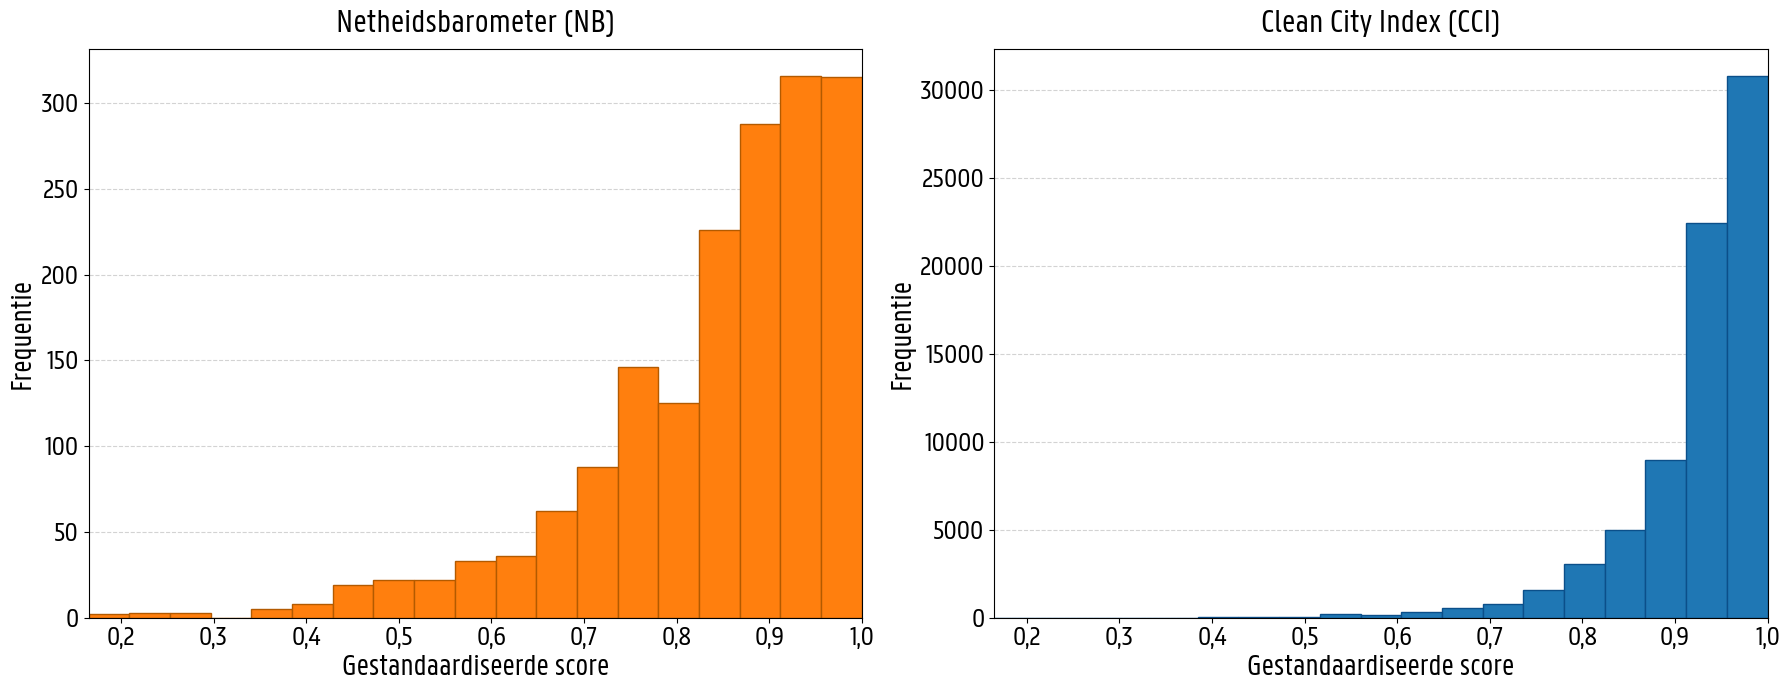

In [ ]:
# =========================
# Data
# =========================
NB = NB_clean.copy()
CCI = CCI_clean.copy()

NB_scores = NB["TOTAAL_std"].dropna()
CCI_scores = CCI["AverageCCI_std"].dropna()

# =========================
# Gezamenlijke bins bepalen
# =========================
all_scores = np.concatenate([NB_scores, CCI_scores])
bins = np.linspace(all_scores.min(), all_scores.max(), 20)

# =========================
# Plot
# =========================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# =========================
# NB histogram
# =========================
axes[0].hist(
    NB_scores,
    bins=bins,
    color="C1",
    edgecolor="#b35a00",
    linewidth=1.0
)

axes[0].set_title(
    "Netheidsbarometer (NB)",
    fontsize=24,
    fontweight="bold",
    pad=12
)

axes[0].set_xlabel(
    "Gestandaardiseerde score",
    fontsize=22,
    fontweight="bold"
)

axes[0].set_ylabel(
    "Frequentie",
    fontsize=22,
    fontweight="bold"
)

# =========================
# CCI histogram
# =========================
axes[1].hist(
    CCI_scores,
    bins=bins,
    color="C0",
    edgecolor="#0b4f8a",
    linewidth=1.0
)

axes[1].set_title(
    "Clean City Index (CCI)",
    fontsize=24,
    fontweight="bold",
    pad=12
)

axes[1].set_xlabel(
    "Gestandaardiseerde score",
    fontsize=22,
    fontweight="bold"
)

axes[1].set_ylabel(
    "Frequentie",
    fontsize=22,
    fontweight="bold"
)

# =========================
# Zelfde x-as
# =========================
axes[0].set_xlim(bins[0], bins[-1])
axes[1].set_xlim(bins[0], bins[-1])

# =========================
# Gridlines ACHTER de balken
# =========================
for ax in axes:

    ax.set_axisbelow(True)

    ax.grid(
        axis="y",
        linestyle="dashed",
        color="lightgray",
        linewidth=0.8,
        zorder=0
    )

    # =========================
    # GROTERE TICK LABELS
    # =========================
    ax.tick_params(
        axis="both",
        labelsize=20
    )

    # =========================
    # Komma als decimaalteken
    # =========================
    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f"{x:.1f}".replace(".", ","))
    )

# =========================
# Layout
# =========================
plt.tight_layout()

# =========================
# Opslaan
# =========================
plt.savefig(
    "histogram_NB_CCI_styled.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\luyck\AppData\Local\Temp\ipykernel_51400\2230548280.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


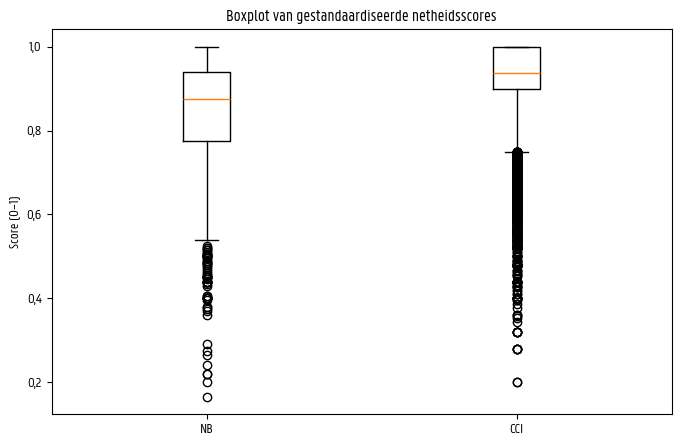


NB
Mean   : 0.841
Median : 0.875
Q1     : 0.775
Q3     : 0.940
IQR    : 0.165

CCI
Mean   : 0.928
Median : 0.938
Q1     : 0.900
Q3     : 1.000
IQR    : 0.100


In [ ]:
# =========================
# Data
# =========================
NB_scores = NB_clean["TOTAAL_std"].dropna()
CCI_scores = CCI_clean["AverageCCI_std"].dropna()

# =========================
# Boxplot
# =========================
fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(
    [NB_scores, CCI_scores],
    labels=["NB", "CCI"],
    vert=True
)

ax.set_title("Boxplot van gestandaardiseerde netheidsscores")
ax.set_ylabel("Score (0–1)")

# =========================
# Punt -> komma
# =========================
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.1f}".replace(".", ","))
)

plt.show()

# =========================
# Statistieken
# =========================
def describe_scores(name, data):
    mean = np.mean(data)
    median = np.median(data)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1

    print(f"\n{name}")
    print(f"Mean   : {mean:.3f}")
    print(f"Median : {median:.3f}")
    print(f"Q1     : {q1:.3f}")
    print(f"Q3     : {q3:.3f}")
    print(f"IQR    : {iqr:.3f}")

describe_scores("NB", NB_scores)
describe_scores("CCI", CCI_scores)

In [49]:
def count_outliers(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = data[(data < lower) | (data > upper)]
    return len(outliers)

print("NB outliers:", count_outliers(NB_scores))
print("CCI outliers:", count_outliers(CCI_scores))

NB outliers: 65
CCI outliers: 2363


# 3.7) Analyse: (NB subset selection)

In [51]:
# ============================================================
# 1. Instellingen
# ============================================================

N_BOOT = 500
OUTPUT_DIR = "fig_temporal_resolution"
DO_PEARSON = False

os.makedirs(OUTPUT_DIR, exist_ok=True)

# NB-gecentreerde vensters
# half_window_days = aantal dagen vóór en na de NB-observatie
WINDOWS = {
    "day": 0,        # enkel NB-dag zelf
    "3days": 1,     # dag ervoor, dag zelf, dag erna
    "week": 3,      # ±3 dagen
    "9days": 4,     # ±4 dagen
    "11days": 5,    # ±5 dagen
    "13days": 6,    # ±6 dagen
    "15days": 7,    # ±7 dagen
    "month": 15,    # ongeveer maandvenster
    "quarter": 45   # ongeveer kwartaalvenster
}

resolution_order = {
    "day": 1,
    "3days": 2,
    "week": 3,
    "9days": 4,
    "11days": 5,
    "13days": 6,
    "15days": 7,
    "month": 8,
    "quarter": 9
}

In [52]:
# ============================================================
# 1. Hulpfuncties
# ============================================================

def normalize_series(s):
    return s.fillna("").astype(str).apply(normalize_street_name)


def add_period_fields(df):
    d = df.copy()
    d["start_date"] = d["period_start"].dt.date
    d["end_date"] = d["period_end"].dt.date
    d["start_time"] = d["period_start"].dt.strftime("%H:%M")
    d["end_time"] = d["period_end"].dt.strftime("%H:%M")
    return d

In [53]:
# ============================================================
# 2. NB-meetduur en tijd tussen metingen berekenen
# ============================================================

NB_time = NB_clean.copy()

NB_time["datum"] = pd.to_datetime(NB_time["datum"], errors="coerce")
NB_time["nb_ts"] = pd.to_datetime(NB_time["nb_ts"], errors="coerce")

NB_time = NB_time[NB_time["nb_ts"].notna()].copy()
NB_time = NB_time.sort_values(["datum", "nb_ts"]).reset_index(drop=True)

# Dagelijkse meetduur
daily_range = (
    NB_time
    .groupby(NB_time["datum"].dt.date)
    .agg(
        start_time=("nb_ts", "min"),
        end_time=("nb_ts", "max"),
        n_obs=("nb_ts", "count")
    )
    .reset_index()
    .rename(columns={"datum": "date_only"})
)

daily_range["duration"] = daily_range["end_time"] - daily_range["start_time"]
daily_range["duration_hours"] = daily_range["duration"].dt.total_seconds() / 3600

daily_range["start_time_str"] = daily_range["start_time"].dt.strftime("%H:%M")
daily_range["end_time_str"] = daily_range["end_time"].dt.strftime("%H:%M")
daily_range["duration_str"] = daily_range["duration"].astype(str).str.split(".").str[0]

# Tijd tussen opeenvolgende metingen
group_key = NB_time["datum"].dt.date

NB_time["prev_ts"] = NB_time.groupby(group_key)["nb_ts"].shift(1)
NB_time["next_ts"] = NB_time.groupby(group_key)["nb_ts"].shift(-1)

NB_time["minutes_since_prev"] = (
    NB_time["nb_ts"] - NB_time["prev_ts"]
).dt.total_seconds() / 60

NB_time["minutes_to_next"] = (
    NB_time["next_ts"] - NB_time["nb_ts"]
).dt.total_seconds() / 60

NB_time["tijd_tussen_metingen"] = np.where(
    NB_time["minutes_since_prev"].notna() & NB_time["minutes_to_next"].notna(),
    NB_time["minutes_since_prev"] + NB_time["minutes_to_next"],
    np.where(
        NB_time["minutes_since_prev"].notna(),
        NB_time["minutes_since_prev"] * 2,
        np.where(
            NB_time["minutes_to_next"].notna(),
            NB_time["minutes_to_next"] * 2,
            np.nan
        )
    )
)

NB_time["tijd_tussen_metingen"] = NB_time["tijd_tussen_metingen"].round(1)

NB_valid = NB_time[NB_time["tijd_tussen_metingen"].notna()].copy()

daily_gap = (
    NB_valid
    .groupby(NB_valid["datum"].dt.date)
    .agg(
        mean_tijd_tussen_metingen=("tijd_tussen_metingen", "mean"),
        median_tijd_tussen_metingen=("tijd_tussen_metingen", "median")
    )
    .reset_index()
    .rename(columns={"datum": "date_only"})
)

In [54]:
# ============================================================
# 3. Verdeling meetduur per dag
# ============================================================

duration_df = daily_range.copy()

bins = [0, 1, 2, 3, 4, 5, 6, 24]
labels = ["0–1u", "1–2u", "2–3u", "3–4u", "4–5u", "5–6u", "6u+"]

duration_df["duration_class"] = pd.cut(
    duration_df["duration_hours"],
    bins=bins,
    labels=labels,
    right=True
)

duration_df = duration_df.merge(
    daily_gap,
    on="date_only",
    how="left"
)

days_per_class = (
    duration_df["duration_class"]
    .value_counts()
    .sort_index()
    .reindex(labels, fill_value=0)
)

obs_per_class = (
    duration_df
    .groupby("duration_class", observed=False)["n_obs"]
    .sum()
    .reindex(labels, fill_value=0)
)

avg_obs_per_day = (
    duration_df
    .groupby("duration_class", observed=False)["n_obs"]
    .mean()
    .reindex(labels)
)

gap_per_class = (
    duration_df
    .groupby("duration_class", observed=False)["mean_tijd_tussen_metingen"]
    .mean()
    .reindex(labels)
)

print("Verdeling meetduur per dag:")
for cls in labels:
    print(
        f"{cls}: "
        f"{days_per_class[cls]} dagen | "
        f"{obs_per_class[cls]} observaties | "
        f"gem. observaties/dag: {avg_obs_per_day[cls]:.1f} | "
        f"gem. tijd tussen metingen: {gap_per_class[cls]:.1f} min"
    )

Verdeling meetduur per dag:
0–1u: 55 dagen | 1085 observaties | gem. observaties/dag: 19.7 | gem. tijd tussen metingen: 1.5 min
1–2u: 7 dagen | 140 observaties | gem. observaties/dag: 20.0 | gem. tijd tussen metingen: 15.0 min
2–3u: 4 dagen | 60 observaties | gem. observaties/dag: 15.0 | gem. tijd tussen metingen: 23.3 min
3–4u: 4 dagen | 60 observaties | gem. observaties/dag: 15.0 | gem. tijd tussen metingen: 47.7 min
4–5u: 3 dagen | 54 observaties | gem. observaties/dag: 18.0 | gem. tijd tussen metingen: 33.9 min
5–6u: 7 dagen | 142 observaties | gem. observaties/dag: 20.3 | gem. tijd tussen metingen: 34.6 min
6u+: 7 dagen | 172 observaties | gem. observaties/dag: 24.6 | gem. tijd tussen metingen: 36.3 min


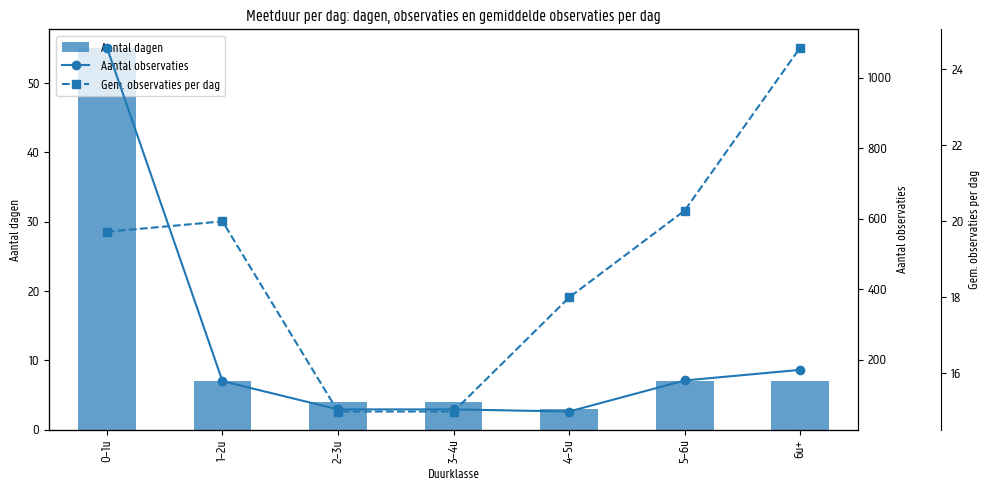

In [55]:
# ============================================================
# 4. Grafiek meetduur NB
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

days_per_class.plot(
    kind="bar",
    ax=ax,
    alpha=0.7,
    label="Aantal dagen"
)

ax.set_xlabel("Duurklasse")
ax.set_ylabel("Aantal dagen")

ax2 = ax.twinx()

obs_per_class.plot(
    kind="line",
    marker="o",
    ax=ax2,
    label="Aantal observaties"
)

ax2.set_ylabel("Aantal observaties")

ax3 = ax.twinx()
ax3.spines["right"].set_position(("outward", 60))

avg_obs_per_day.plot(
    kind="line",
    marker="s",
    linestyle="--",
    ax=ax3,
    label="Gem. observaties per dag"
)

ax3.set_ylabel("Gem. observaties per dag")

plt.title("Meetduur per dag: dagen, observaties en gemiddelde observaties per dag")

handles, labels_legend = [], []
for axis in [ax, ax2, ax3]:
    h, l = axis.get_legend_handles_labels()
    handles += h
    labels_legend += l

ax.legend(handles, labels_legend, loc="upper left")

plt.tight_layout()
plt.show()

# 3.7.1) Temporele aggregatie

In [56]:
# ============================================================
# 6. CCI beperken tot overlappende straten
# ============================================================

matched_streets = (
    matched_index
    .loc[matched_index["NB_straten"].notna(), "CCI_straten"]
    .dropna()
    .unique()
)

CCI_subset = CCI_clean[
    CCI_clean["CCI_straten"].isin(matched_streets)
].copy()

print(f"Originele CCI-rijen: {len(CCI_clean)}")
print(f"CCI-rijen op overlappende straten: {len(CCI_subset)}")

Originele CCI-rijen: 73996
CCI-rijen op overlappende straten: 7152


In [57]:
# ============================================================
# 7. CCI voorbereiden
# ============================================================

def prepare_cci(df):
    d = df.copy()

    d["datum"] = pd.to_datetime(d["datum"], errors="coerce")
    d["start_ts"] = pd.to_datetime(d["start_ts"], errors="coerce")
    d["end_ts"] = pd.to_datetime(d["end_ts"], errors="coerce")
    d["AverageCCI_std"] = pd.to_numeric(d["AverageCCI_std"], errors="coerce")

    if "snapshots" in d.columns:
        d["snapshots"] = pd.to_numeric(d["snapshots"], errors="coerce")
    else:
        d["snapshots"] = pd.NA

    if "Segments" in d.columns:
        d["Segments"] = pd.to_numeric(d["Segments"], errors="coerce")
    else:
        d["Segments"] = pd.NA

    d = d[d["start_ts"].notna()].copy()

    return d


cci_prepared = prepare_cci(CCI_subset)

# ============================================================
# 7b. NB voorbereiden voor NB-gecentreerde koppeling
# ============================================================

def prepare_nb_for_join(nb_df, matched_index):
    nb = nb_df.copy()
    mi = matched_index.copy()

    nb["datum"] = pd.to_datetime(nb["datum"], errors="coerce")
    nb["nb_ts"] = pd.to_datetime(nb["nb_ts"], errors="coerce")

    nb = nb[nb["nb_ts"].notna()].copy()

    nb["NB_straten_norm"] = normalize_series(nb["NB_straten"])
    mi["NB_straten_norm"] = normalize_series(mi["NB_straten"])

    nb_to_cci = (
        mi.dropna(subset=["NB_straten", "CCI_straten"])
        .drop_duplicates("NB_straten_norm")
        .set_index("NB_straten_norm")["CCI_straten"]
        .to_dict()
    )

    nb["CCI_straten"] = nb["NB_straten_norm"].map(nb_to_cci)
    nb = nb[nb["CCI_straten"].notna()].copy()

    return nb


NB_mapped = prepare_nb_for_join(NB_clean, matched_index)

print(f"NB-observaties gebruikt voor koppeling: {len(NB_mapped)}")
print(f"Aantal unieke NB-straten: {NB_mapped['NB_straten'].nunique()}")
print(f"Aantal unieke gekoppelde CCI-straten: {NB_mapped['CCI_straten'].nunique()}")

NB-observaties gebruikt voor koppeling: 1719
Aantal unieke NB-straten: 62
Aantal unieke gekoppelde CCI-straten: 62


In [58]:
# ============================================================
# 8. NB-gecentreerde temporele koppeling met CCI
# ============================================================

def match_cci_around_nb(nb_mapped, cci_prepared, resolution_label, half_window_days):
    """
    Voor elke NB-observatie wordt gezocht naar CCI-observaties
    van dezelfde straat binnen een symmetrisch tijdsvenster rond
    de NB-datum.
    """

    nb = nb_mapped.copy()
    cci = cci_prepared.copy()

    nb["nb_ts"] = pd.to_datetime(nb["nb_ts"], errors="coerce")
    nb["nb_date"] = nb["nb_ts"].dt.normalize()

    cci["start_ts"] = pd.to_datetime(cci["start_ts"], errors="coerce")
    cci["AverageCCI_std"] = pd.to_numeric(cci["AverageCCI_std"], errors="coerce")

    nb = nb[nb["nb_date"].notna()].copy()
    cci = cci[cci["start_ts"].notna()].copy()

    # Unieke NB-observatie-id
    nb = nb.reset_index(drop=True)
    nb["NB_obs_id"] = nb.index

    # Tijdvenster rond NB-observatie
    nb["period_start"] = nb["nb_date"] - pd.Timedelta(days=half_window_days)
    nb["period_end"] = nb["nb_date"] + pd.Timedelta(days=half_window_days + 1)

    # Merge op straat
    merged = nb.merge(
        cci,
        on="CCI_straten",
        how="left",
        suffixes=("_NB", "_CCI")
    )

    # CCI-observaties binnen NB-gecentreerd venster
    cond = (
        merged["start_ts"].notna()
        & (merged["start_ts"] >= merged["period_start"])
        & (merged["start_ts"] < merged["period_end"])
    )

    matched = merged.loc[cond].copy()

    # Aggregatie per NB-observatie
    grouped = (
        matched
        .groupby(
            [
                "NB_obs_id",
                "CCI_straten",
                "period_start",
                "period_end",
                "nb_ts"
            ],
            dropna=False
        )
        .agg(
            CCI_std=("AverageCCI_std", "mean"),
            NB_std=("TOTAAL_std", "mean"),
            ZW_std=("ZW_score_std", "mean"),
            PA_std=("PA_score_std", "mean"),
            SL_std=("SL_score_std", "mean"),
            VA_std=("VA_score_std", "mean"),
            EF_std=("EF_score_std", "mean"),
            observations=("AverageCCI_std", "count"),
            snapshots_mean=("snapshots", "mean"),
            Segments_mean=("Segments", "mean")
        )
        .reset_index()
    )

    grouped["resolution"] = resolution_label
    grouped["half_window_days"] = half_window_days
    grouped["window_days"] = half_window_days * 2 + 1

    return grouped


CCI_NB = {}

for label, half_window in WINDOWS.items():
    CCI_NB[label] = match_cci_around_nb(
        nb_mapped=NB_mapped,
        cci_prepared=cci_prepared,
        resolution_label=label,
        half_window_days=half_window
    )

for label in CCI_NB:
    print(f"{label}: {len(CCI_NB[label])} gekoppelde NB-observaties")

day: 263 gekoppelde NB-observaties
3days: 449 gekoppelde NB-observaties
week: 660 gekoppelde NB-observaties
9days: 720 gekoppelde NB-observaties
11days: 775 gekoppelde NB-observaties
13days: 851 gekoppelde NB-observaties
15days: 902 gekoppelde NB-observaties
month: 1109 gekoppelde NB-observaties
quarter: 1395 gekoppelde NB-observaties


In [59]:
# ============================================================
# 9. MASTER-tabel maken
# ============================================================

MASTER = pd.concat(
    [df for df in CCI_NB.values()],
    ignore_index=True
)

print(MASTER.head())
print(MASTER["resolution"].value_counts())

   NB_obs_id             CCI_straten period_start period_end  \
0         22           Heerweg-Noord   2024-01-25 2024-01-26   
1         25     Zwijnaardsesteenweg   2024-01-25 2024-01-26   
2         27        Loofblommestraat   2024-01-25 2024-01-26   
3         33  Koningin Elisabethlaan   2024-01-25 2024-01-26   
4         35       Drongensesteenweg   2024-01-25 2024-01-26   

                nb_ts  CCI_std  NB_std  ZW_std  PA_std  SL_std  VA_std  \
0 2024-01-25 09:40:00    0.950   0.980   0.900     1.0    1.00    1.00   
1 2024-01-25 10:09:00    0.902   0.845   0.725     1.0    1.00    0.75   
2 2024-01-25 10:40:00    0.934   0.935   0.925     1.0    1.00    1.00   
3 2024-01-25 12:15:00    0.958   0.775   0.875     1.0    1.00    1.00   
4 2024-01-25 12:55:00    0.902   0.670   0.600     1.0    0.75    0.75   

   EF_std  observations  snapshots_mean Segments_mean resolution  \
0    1.00             1            58.0           NaN        day   
1    0.75             1           

In [60]:
# ============================================================
# 10. Stabiliteit per temporeel venster evalueren
# ============================================================

def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)


def evaluate_temporal_resolution(df_res, resolution):
    d = df_res.dropna(subset=["CCI_std", "NB_std"]).copy()

    return {
        "resolution": resolution,
        "N_pairs": len(d),
        "n_streets": d["CCI_straten"].nunique(),

        "CCI_mean": d["CCI_std"].mean(),
        "CCI_sd": d["CCI_std"].std(ddof=1),
        "CCI_iqr": iqr(d["CCI_std"]),

        "NB_mean": d["NB_std"].mean(),
        "NB_sd": d["NB_std"].std(ddof=1),
        "NB_iqr": iqr(d["NB_std"]),

        "mean_CCI_observations": d["observations"].mean(),
        "median_CCI_observations": d["observations"].median(),
        "mean_window_days": d["window_days"].mean()
    }


resolution_results = []

for res_key in sorted(MASTER["resolution"].unique(), key=lambda x: resolution_order.get(x, 999)):
    df_res = MASTER[MASTER["resolution"] == res_key]
    stats = evaluate_temporal_resolution(df_res, res_key)
    resolution_results.append(stats)

resolution_df = pd.DataFrame(resolution_results)
resolution_df["resolution_order"] = resolution_df["resolution"].map(resolution_order)
resolution_df = resolution_df.sort_values("resolution_order")

print(resolution_df)

resolution_df.to_csv(
    os.path.join(OUTPUT_DIR, "temporal_resolution_stability_NB_centered.csv"),
    index=False
)

  resolution  N_pairs  n_streets  CCI_mean    CCI_sd   CCI_iqr   NB_mean  \
0        day      263         59  0.902558  0.076993  0.088000  0.801749   
1      3days      449         61  0.907598  0.075292  0.083000  0.805939   
2       week      660         61  0.906140  0.076111  0.084375  0.813866   
3      9days      720         61  0.906671  0.075993  0.084000  0.813356   
4     11days      775         62  0.905344  0.077599  0.085125  0.813505   
5     13days      851         62  0.904904  0.077589  0.087125  0.816028   
6     15days      902         62  0.907234  0.075173  0.082000  0.819113   
7      month     1109         62  0.911393  0.069054  0.080000  0.824076   
8    quarter     1395         62  0.907847  0.063816  0.075271  0.831550   

      NB_sd    NB_iqr  mean_CCI_observations  median_CCI_observations  \
0  0.160809  0.197500               1.357414                      1.0   
1  0.156148  0.190000               1.890869                      1.0   
2  0.148916  0.17500

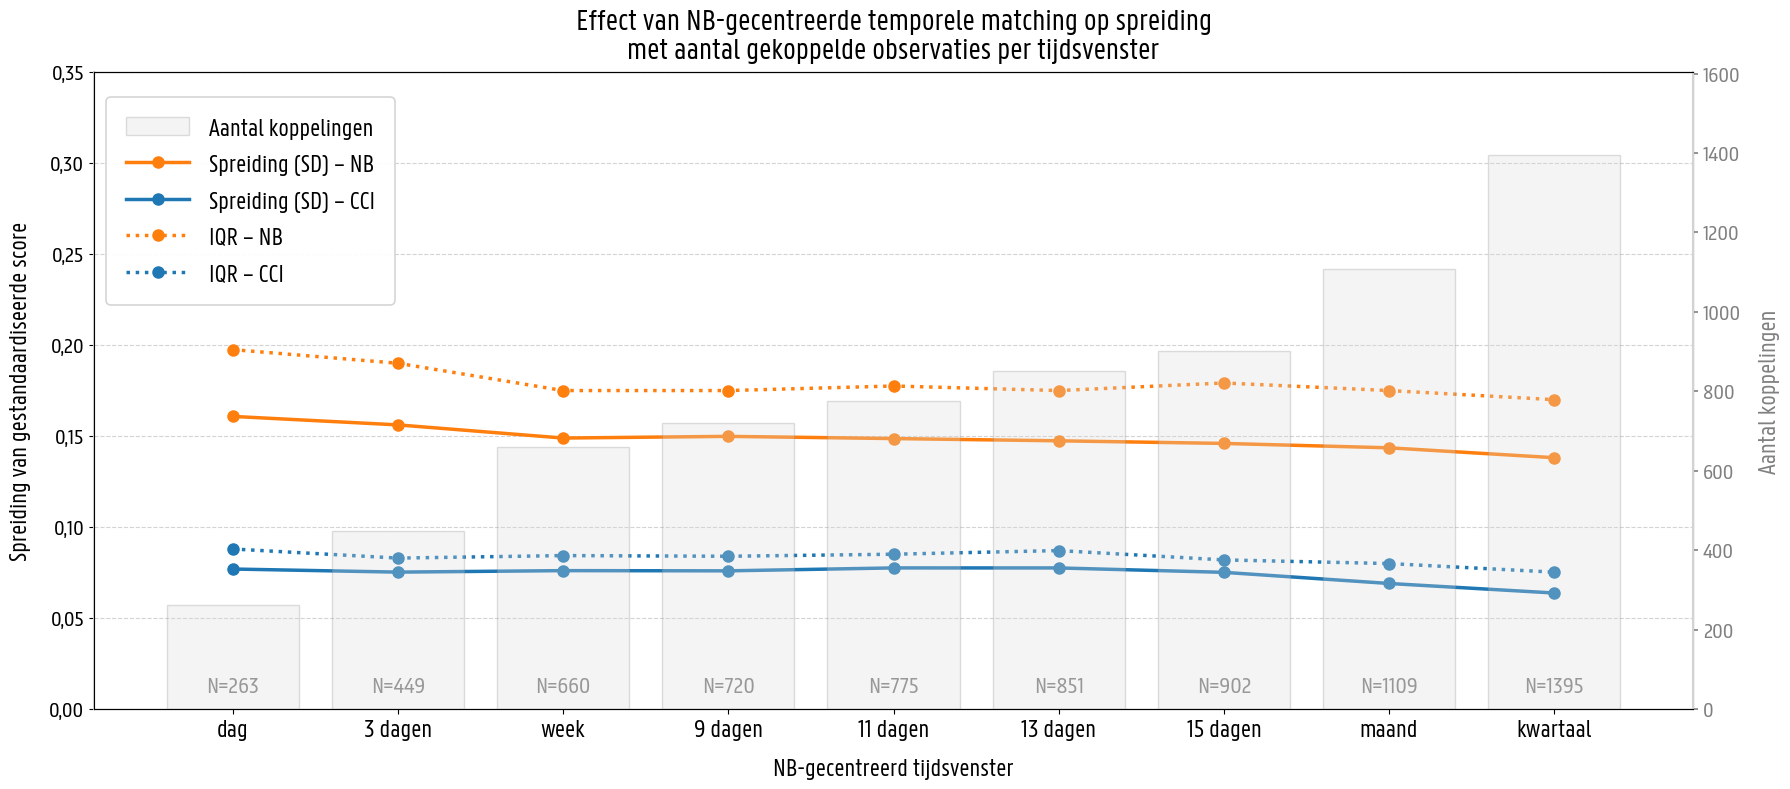

In [ ]:
# ============================================================
# 11. Figuur: effect van NB-gecentreerde temporele vensters
# ============================================================


df = resolution_df.sort_values("resolution_order")

resolution_nl = {
    "day": "dag",
    "3days": "3 dagen",
    "week": "week",
    "9days": "9 dagen",
    "11days": "11 dagen",
    "13days": "13 dagen",
    "15days": "15 dagen",
    "month": "maand",
    "quarter": "kwartaal"
}

x = np.arange(len(df))
labels = [resolution_nl.get(r, r) for r in df["resolution"]]
Ns = df["N_pairs"].values

sd_nb = df["NB_sd"].values
sd_cci = df["CCI_sd"].values

iqr_nb = df["NB_iqr"].values
iqr_cci = df["CCI_iqr"].values

fig, ax_left = plt.subplots(figsize=(18, 8))

# ==============================
# Rechter y-as – aantal koppelingen
# ==============================
ax_right = ax_left.twinx()

ax_right.bar(
    x,
    Ns,
    alpha=0.28,
    color="#d9d9d9",
    edgecolor="#8c8c8c",
    linewidth=1.0,
    label="Aantal koppelingen",
    zorder=0
)

ax_right.set_ylabel(
    "Aantal koppelingen",
    color="grey",
    fontsize=18,
    fontweight="bold",
    labelpad=13
)

ax_right.tick_params(
    axis="y",
    labelcolor="grey",
    labelsize=16
)

ax_right.set_ylim(0, np.nanmax(Ns) * 1.15)

# ==============================
# Punt -> komma rechter y-as
# ==============================
ax_right.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.0f}".replace(".", ","))
)

# ==============================
# Lichtgrijze rechter y-as lijn + ticks
# ==============================
ax_right.spines["right"].set_visible(True)
ax_right.spines["right"].set_color("lightgray")
ax_right.spines["right"].set_linewidth(1.5)

ax_right.tick_params(
    axis="y",
    colors="grey",
    width=1.2
)

# ==============================
# Spreiding – SD
# ==============================
ax_left.plot(
    x,
    sd_nb,
    marker="o",
    linestyle="-",
    color="C1",
    linewidth=2.5,
    markersize=8,
    label="Spreiding (SD) – NB",
    zorder=3
)

ax_left.plot(
    x,
    sd_cci,
    marker="o",
    linestyle="-",
    color="C0",
    linewidth=2.5,
    markersize=8,
    label="Spreiding (SD) – CCI",
    zorder=3
)

# ==============================
# Spreiding – IQR
# ==============================
ax_left.plot(
    x,
    iqr_nb,
    marker="o",
    linestyle=":",
    color="C1",
    linewidth=2.5,
    markersize=8,
    label="IQR – NB",
    zorder=3
)

ax_left.plot(
    x,
    iqr_cci,
    marker="o",
    linestyle=":",
    color="C0",
    linewidth=2.5,
    markersize=8,
    label="IQR – CCI",
    zorder=3
)

# ==============================
# Linker y-as
# ==============================
ax_left.set_ylabel(
    "Spreiding van gestandaardiseerde score",
    fontsize=18,
    fontweight="bold",
    labelpad=13
)

ax_left.tick_params(axis="y", labelsize=16)
ax_left.set_ylim(0, 0.35)

# ==============================
# Punt -> komma linker y-as
# ==============================
ax_left.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.2f}".replace(".", ","))
)

# ==============================
# Lichtgrijze linker y-as lijn
# ==============================
ax_left.spines["left"].set_color("lightgray")
ax_left.spines["left"].set_linewidth(1.5)

# ==============================
# X-as
# ==============================
ax_left.set_xticks(x)

ax_left.set_xticklabels(
    labels,
    fontsize=18
)

ax_left.set_xlabel(
    "NB-gecentreerd tijdsvenster",
    fontsize=18,
    fontweight="bold",
    labelpad=13
)

# ==============================
# Gridlines achter de lijnen
# ==============================
ax_left.set_axisbelow(True)

ax_left.grid(
    axis="y",
    linestyle="dashed",
    color="lightgray",
    linewidth=0.8,
    zorder=0
)

# ==============================
# N net boven de x-as
# ==============================
for xi, Ni in zip(x, Ns):
    ax_left.text(
        xi,
        0.02,
        f"N={Ni}",
        ha="center",
        va="bottom",
        fontsize=17,
        color="grey",
        transform=ax_left.get_xaxis_transform()
    )

# ==============================
# Titel
# ==============================
ax_left.set_title(
    "Effect van NB-gecentreerde temporele matching op spreiding\n"
    "met aantal gekoppelde observaties per tijdsvenster",
    fontsize=22,
    fontweight="bold",
    pad=10
)

# ==============================
# Legende iets lager
# ==============================
h1, l1 = ax_left.get_legend_handles_labels()
h2, l2 = ax_right.get_legend_handles_labels()

handles = h2 + h1
legend_labels = l2 + l1

legend = ax_left.legend(
    handles,
    legend_labels,
    loc="upper left",
    bbox_to_anchor=(0, 0.98),
    fontsize=18,
    labelspacing=0.6,
    handlelength=2.5,
    frameon=True,
    fancybox=True,
    framealpha=0.95,
    borderpad=0.8
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("lightgray")
legend.get_frame().set_linewidth(1.2)

plt.tight_layout()

plt.savefig(
    "effect_temporele_vensters_styled.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [62]:
# ============================================================
# 12. Print overzicht
# ============================================================

print("\n=== Overzicht per NB-gecentreerd tijdsvenster ===\n")

for _, row in df.iterrows():
    res = row["resolution"]
    res_nl = resolution_nl.get(res, res)

    print(f"Venster: {res_nl}")
    print(f"  Aantal koppelingen (N): {int(row['N_pairs'])}")
    print(f"  Aantal unieke straten: {int(row['n_streets'])}")
    print(f"  NB  - SD: {row['NB_sd']:.4f} | IQR: {row['NB_iqr']:.4f}")
    print(f"  CCI - SD: {row['CCI_sd']:.4f} | IQR: {row['CCI_iqr']:.4f}")
    print(f"  Gem. CCI-observaties per match: {row['mean_CCI_observations']:.1f}")
    print("-" * 45)


summary = df[[
    "resolution",
    "N_pairs",
    "n_streets",
    "NB_sd", "NB_iqr",
    "CCI_sd", "CCI_iqr",
    "mean_CCI_observations"
]].copy()

summary["resolution"] = summary["resolution"].map(resolution_nl)

summary = summary.rename(columns={
    "resolution": "Venster",
    "N_pairs": "N koppelingen",
    "n_streets": "Unieke straten",
    "NB_sd": "NB SD",
    "NB_iqr": "NB IQR",
    "CCI_sd": "CCI SD",
    "CCI_iqr": "CCI IQR",
    "mean_CCI_observations": "Gem. CCI obs/match"
})

print("\n=== Samenvattingstabel ===\n")
print(summary.to_string(index=False))


=== Overzicht per NB-gecentreerd tijdsvenster ===

Venster: dag
  Aantal koppelingen (N): 263
  Aantal unieke straten: 59
  NB  - SD: 0.1608 | IQR: 0.1975
  CCI - SD: 0.0770 | IQR: 0.0880
  Gem. CCI-observaties per match: 1.4
---------------------------------------------
Venster: 3 dagen
  Aantal koppelingen (N): 449
  Aantal unieke straten: 61
  NB  - SD: 0.1561 | IQR: 0.1900
  CCI - SD: 0.0753 | IQR: 0.0830
  Gem. CCI-observaties per match: 1.9
---------------------------------------------
Venster: week
  Aantal koppelingen (N): 660
  Aantal unieke straten: 61
  NB  - SD: 0.1489 | IQR: 0.1750
  CCI - SD: 0.0761 | IQR: 0.0844
  Gem. CCI-observaties per match: 2.6
---------------------------------------------
Venster: 9 dagen
  Aantal koppelingen (N): 720
  Aantal unieke straten: 61
  NB  - SD: 0.1498 | IQR: 0.1750
  CCI - SD: 0.0760 | IQR: 0.0840
  Gem. CCI-observaties per match: 2.9
---------------------------------------------
Venster: 11 dagen
  Aantal koppelingen (N): 775
  Aanta

# 3.7.2) Patroonovereenkomst 

Aantal gekoppelde observaties (week): 660
Aantal unieke straten: 61

=== Correlatieanalyse CCI vs NB ===

                Variabele  Kolom   N  Spearman_rho   Spearman_p  Pearson_r    Pearson_p
                NB totaal NB_std 660      0.311533 2.547647e-16   0.288121 4.399886e-14
                Zwerfvuil ZW_std 660      0.214452 2.639984e-08   0.258687 1.494840e-11
     Publieke afvalkorven PA_std 660      0.093332 1.646501e-02   0.084733 2.950988e-02
               Sluikstort SL_std 660      0.328212 4.848735e-18   0.301622 2.388790e-15
Verkeerd aangeboden afval VA_std 660      0.185015 1.705713e-06   0.159467 3.865637e-05
         Externe factoren EF_std 660      0.105886 6.473694e-03   0.074800 5.477039e-02


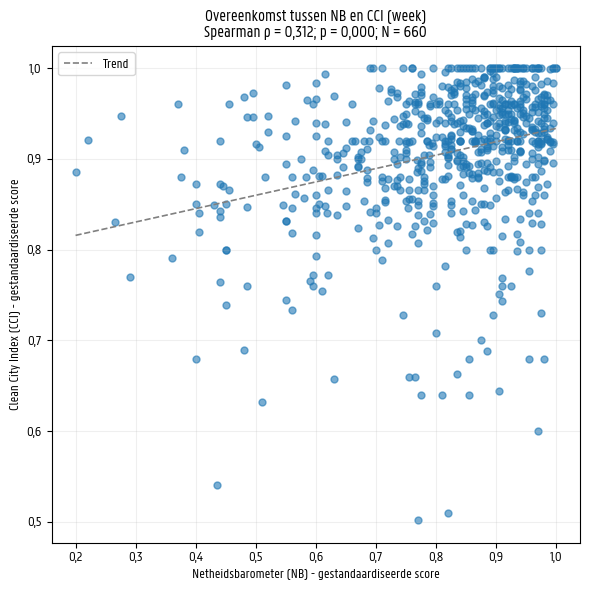

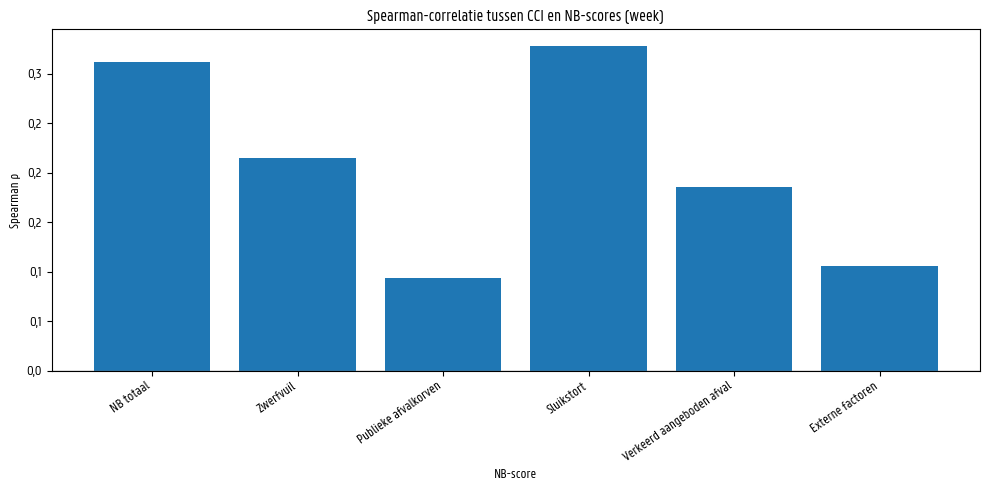

In [ ]:
# ============================================================
# 3.7.2 OVEREENKOMST: CCI vs NB op gekozen resolutie
# ============================================================

# ============================================================
# 1. Instellingen
# ============================================================

OUTPUT_DIR = "fig_agreement_pattern"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CHOSEN_RESOLUTION = "week"
DO_PEARSON = True

# ============================================================
# 2. Data selecteren
# ============================================================

df_week = MASTER[
    MASTER["resolution"] == CHOSEN_RESOLUTION
].copy()

df_week = df_week.dropna(subset=["CCI_std", "NB_std"]).copy()

print(f"Aantal gekoppelde observaties ({CHOSEN_RESOLUTION}): {len(df_week)}")
print(f"Aantal unieke straten: {df_week['CCI_straten'].nunique()}")

# ============================================================
# 3. Correlatie CCI vs NB totaal en NB-deelscores
# ============================================================

target_cols = {
    "NB_std": "NB totaal",
    "ZW_std": "Zwerfvuil",
    "PA_std": "Publieke afvalkorven",
    "SL_std": "Sluikstort",
    "VA_std": "Verkeerd aangeboden afval",
    "EF_std": "Externe factoren"
}

corr_results = []

for col, label in target_cols.items():

    pair = df_week.dropna(subset=["CCI_std", col]).copy()
    n = len(pair)

    if n >= 2:

        sp = spearmanr(pair["CCI_std"], pair[col])

        spearman_r = sp.correlation
        spearman_p = sp.pvalue

        if DO_PEARSON:

            pe = pearsonr(pair["CCI_std"], pair[col])

            pearson_r = pe[0]
            pearson_p = pe[1]

        else:

            pearson_r = np.nan
            pearson_p = np.nan

    else:

        spearman_r = np.nan
        spearman_p = np.nan
        pearson_r = np.nan
        pearson_p = np.nan

    corr_results.append({
        "Variabele": label,
        "Kolom": col,
        "N": n,
        "Spearman_rho": spearman_r,
        "Spearman_p": spearman_p,
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p
    })

corr_df = pd.DataFrame(corr_results)

print("\n=== Correlatieanalyse CCI vs NB ===\n")
print(corr_df.to_string(index=False))

corr_df.to_csv(
    os.path.join(OUTPUT_DIR, f"correlatie_CCI_NB_{CHOSEN_RESOLUTION}.csv"),
    index=False
)

# ============================================================
# 4. Scatterplot CCI vs NB met regressielijn
# ============================================================

pair = df_week.dropna(subset=["CCI_std", "NB_std"]).copy()

sp = spearmanr(pair["CCI_std"], pair["NB_std"])

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    pair["NB_std"],
    pair["CCI_std"],
    alpha=0.6,
    s=25
)

# ============================================================
# Regressielijn
# ============================================================

z = np.polyfit(pair["NB_std"], pair["CCI_std"], 1)
p = np.poly1d(z)

x_sorted = np.sort(pair["NB_std"])

ax.plot(
    x_sorted,
    p(x_sorted),
    color="grey",
    linewidth=1.2,
    linestyle="--",
    label="Trend"
)

ax.set_xlabel("Netheidsbarometer (NB) - gestandaardiseerde score")
ax.set_ylabel("Clean City Index (CCI) - gestandaardiseerde score")

# ============================================================
# Punt -> komma
# Komma's -> puntkomma's
# ============================================================

rho_text = f"{sp.correlation:.3f}".replace(".", ",")
p_text = f"{sp.pvalue:.3f}".replace(".", ",")

ax.set_title(
    f"Overeenkomst tussen NB en CCI ({CHOSEN_RESOLUTION})\n"
    f"Spearman ρ = {rho_text}; p = {p_text}; N = {len(pair)}"
)

# ============================================================
# Punt -> komma op assen
# ============================================================

formatter = FuncFormatter(lambda x, pos: f"{x:.1f}".replace(".", ","))

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, f"scatter_CCI_NB_{CHOSEN_RESOLUTION}_trend.png"),
    dpi=300
)

plt.show()

# ============================================================
# 5. Staafdiagram correlaties met NB totaal en deelscores
# ============================================================

plot_df = corr_df.copy()

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    plot_df["Variabele"],
    plot_df["Spearman_rho"]
)

ax.axhline(0, color="grey", linewidth=1)

ax.set_ylabel("Spearman ρ")
ax.set_xlabel("NB-score")

ax.set_title(
    f"Spearman-correlatie tussen CCI en NB-scores ({CHOSEN_RESOLUTION})"
)

plt.xticks(rotation=35, ha="right")

# ============================================================
# Punt -> komma op y-as
# ============================================================

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.1f}".replace(".", ","))
)

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, f"spearman_CCI_NB_subscores_{CHOSEN_RESOLUTION}.png"),
    dpi=300
)

plt.show()

# 3.7.3) Agreement

Aantal gekoppelde observaties (week): 660
Aantal unieke straten: 61

=== Agreement analyse CCI vs NB ===

resolution   N  n_streets  bias_mean_diff  sd_diff  loa_lower  loa_upper  loa_width     rmse      mae  percent_within_loa
      week 660         61        0.092274 0.146416  -0.194701    0.37925   0.573951 0.172973 0.126911           93.636364


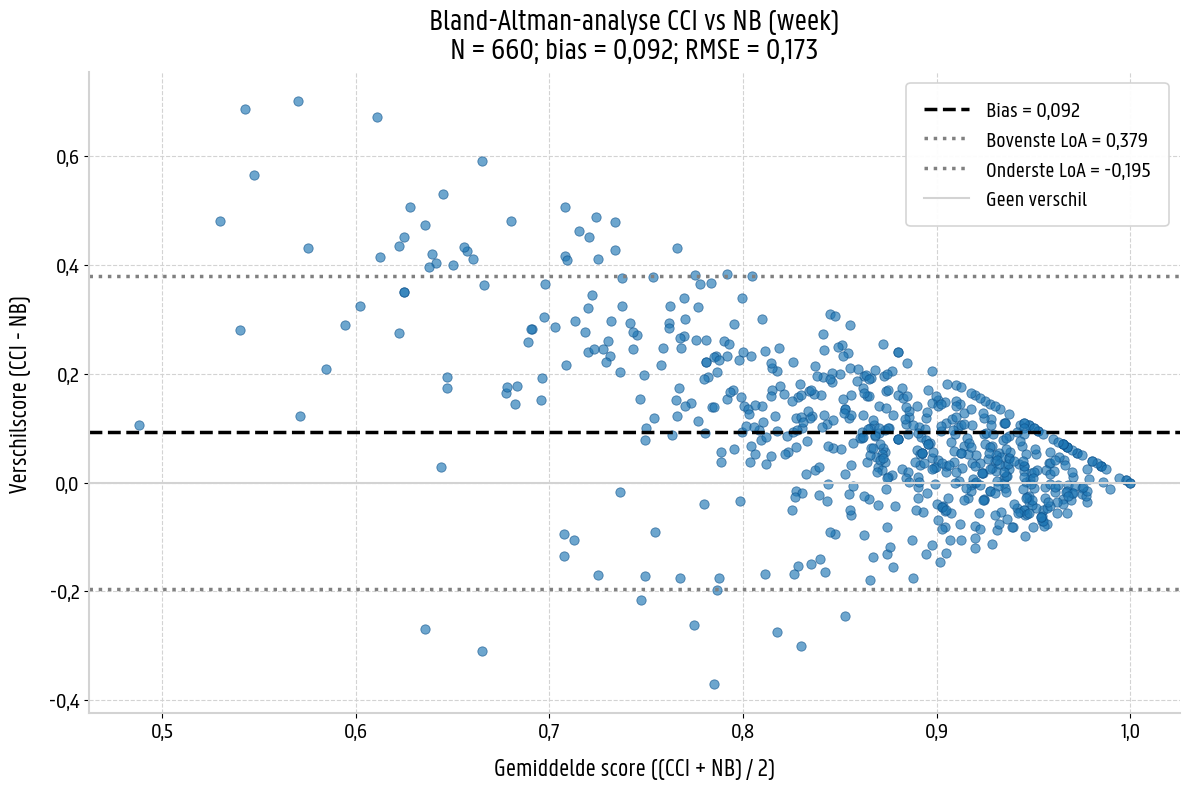

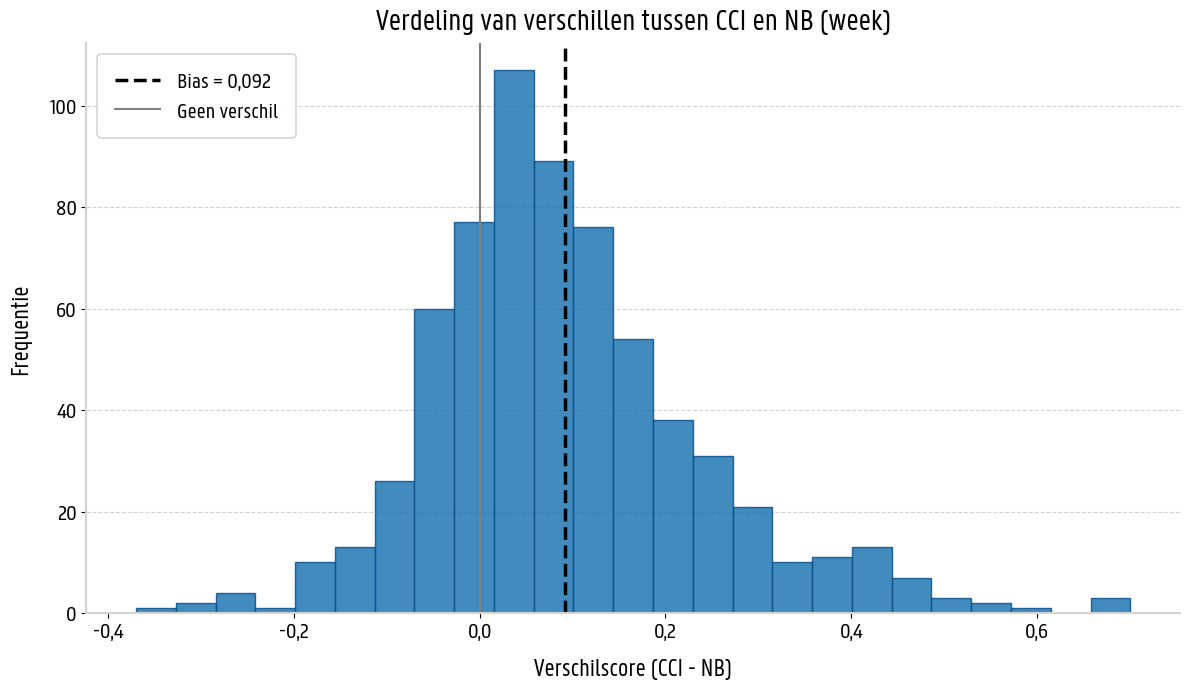


=== Beschrijvende statistiek verschilscore (CCI - NB) ===

count    660.000000
mean       0.092274
std        0.146416
min       -0.370000
25%       -0.000250
50%        0.072000
75%        0.161646
max        0.700476
Name: diff_score, dtype: float64

Interpretatie:
Gemiddeld verschil (bias): 0,092
Limits of agreement: [-0,195; 0,379]
RMSE: 0,173
MAE: 0,127
Percentage binnen LoA: 93,6%


In [ ]:
# ============================================================
# 3.7.3 AGREEMENT: CCI vs NB op gekozen resolutie
# ============================================================

# ============================================================
# 1. Instellingen
# ============================================================

OUTPUT_DIR = "fig_agreement_values"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CHOSEN_RESOLUTION = "week"

# ============================================================
# 2. Data selecteren
# ============================================================

df_agree = MASTER[
    MASTER["resolution"] == CHOSEN_RESOLUTION
].copy()

df_agree = df_agree.dropna(subset=["CCI_std", "NB_std"]).copy()

print(f"Aantal gekoppelde observaties ({CHOSEN_RESOLUTION}): {len(df_agree)}")
print(f"Aantal unieke straten: {df_agree['CCI_straten'].nunique()}")

# ============================================================
# 3. Verschilscore en gemiddelde score berekenen
# ============================================================

df_agree["mean_score"] = (df_agree["CCI_std"] + df_agree["NB_std"]) / 2
df_agree["diff_score"] = df_agree["CCI_std"] - df_agree["NB_std"]

# ============================================================
# 4. Bland-Altman statistieken
# ============================================================

bias = df_agree["diff_score"].mean()
sd_diff = df_agree["diff_score"].std(ddof=1)

loa_lower = bias - 1.96 * sd_diff
loa_upper = bias + 1.96 * sd_diff
loa_width = loa_upper - loa_lower

rmse = np.sqrt(np.mean(df_agree["diff_score"] ** 2))
mae = np.mean(np.abs(df_agree["diff_score"]))

within_loa = (
    (df_agree["diff_score"] >= loa_lower) &
    (df_agree["diff_score"] <= loa_upper)
).mean() * 100

agreement_summary = pd.DataFrame([{
    "resolution": CHOSEN_RESOLUTION,
    "N": len(df_agree),
    "n_streets": df_agree["CCI_straten"].nunique(),
    "bias_mean_diff": bias,
    "sd_diff": sd_diff,
    "loa_lower": loa_lower,
    "loa_upper": loa_upper,
    "loa_width": loa_width,
    "rmse": rmse,
    "mae": mae,
    "percent_within_loa": within_loa
}])

print("\n=== Agreement analyse CCI vs NB ===\n")
print(agreement_summary.to_string(index=False))

agreement_summary.to_csv(
    os.path.join(OUTPUT_DIR, f"agreement_summary_{CHOSEN_RESOLUTION}.csv"),
    index=False
)

# ============================================================
# 5. Bland-Altman plot
# ============================================================

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    df_agree["mean_score"],
    df_agree["diff_score"],
    alpha=0.65,
    s=45,
    color="C0",
    edgecolor="#0b4f8a",
    linewidth=0.6
)

# ============================================================
# Punt -> komma
# ============================================================

bias_text = f"{bias:.3f}".replace(".", ",")
loa_upper_text = f"{loa_upper:.3f}".replace(".", ",")
loa_lower_text = f"{loa_lower:.3f}".replace(".", ",")
rmse_text = f"{rmse:.3f}".replace(".", ",")

ax.axhline(
    bias,
    linestyle="--",
    linewidth=2.5,
    color="black",
    label=f"Bias = {bias_text}"
)

ax.axhline(
    loa_upper,
    linestyle=":",
    linewidth=2.5,
    color="grey",
    label=f"Bovenste LoA = {loa_upper_text}"
)

ax.axhline(
    loa_lower,
    linestyle=":",
    linewidth=2.5,
    color="grey",
    label=f"Onderste LoA = {loa_lower_text}"
)

ax.axhline(
    0,
    linestyle="-",
    linewidth=1.5,
    color="lightgrey",
    label="Geen verschil"
)

ax.set_xlabel(
    "Gemiddelde score ((CCI + NB) / 2)",
    fontsize=18,
    fontweight="bold",
    labelpad=13
)

ax.set_ylabel(
    "Verschilscore (CCI - NB)",
    fontsize=18,
    fontweight="bold",
    labelpad=13
)

ax.set_title(
    f"Bland-Altman-analyse CCI vs NB ({CHOSEN_RESOLUTION})\n"
    f"N = {len(df_agree)}; bias = {bias_text}; RMSE = {rmse_text}",
    fontsize=22,
    fontweight="bold",
    pad=10
)

# ============================================================
# Punt -> komma op assen
# ============================================================

formatter = FuncFormatter(lambda x, pos: f"{x:.1f}".replace(".", ","))

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

ax.tick_params(axis="both", labelsize=16)

ax.set_axisbelow(True)
ax.grid(
    axis="both",
    linestyle="dashed",
    color="lightgray",
    linewidth=0.8,
    zorder=0
)

# ============================================================
# Randen aanpassen: links/onder lichtgrijs, boven/rechts weg
# ============================================================

ax.spines["left"].set_color("lightgray")
ax.spines["left"].set_linewidth(1.5)

ax.spines["bottom"].set_color("lightgray")
ax.spines["bottom"].set_linewidth(1.5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend = ax.legend(
    loc="upper right",
    fontsize=16,
    frameon=True,
    fancybox=True,
    framealpha=0.95,
    borderpad=0.8
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("lightgray")
legend.get_frame().set_linewidth(1.2)

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, f"bland_altman_CCI_NB_{CHOSEN_RESOLUTION}.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 6. Histogram van verschilscore
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

ax.hist(
    df_agree["diff_score"],
    bins=25,
    alpha=0.85,
    color="C0",
    edgecolor="#0b4f8a",
    linewidth=1.0
)

ax.axvline(
    bias,
    linestyle="--",
    linewidth=2.5,
    color="black",
    label=f"Bias = {bias_text}"
)

ax.axvline(
    0,
    linestyle="-",
    linewidth=1.5,
    color="grey",
    label="Geen verschil"
)

ax.set_xlabel(
    "Verschilscore (CCI - NB)",
    fontsize=18,
    fontweight="bold",
    labelpad=13
)

ax.set_ylabel(
    "Frequentie",
    fontsize=18,
    fontweight="bold",
    labelpad=13
)

ax.set_title(
    f"Verdeling van verschillen tussen CCI en NB ({CHOSEN_RESOLUTION})",
    fontsize=22,
    fontweight="bold",
    pad=10
)

# ============================================================
# Punt -> komma op assen
# ============================================================

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.0f}".replace(".", ","))
)

ax.tick_params(axis="both", labelsize=16)

ax.set_axisbelow(True)
ax.grid(
    axis="y",
    linestyle="dashed",
    color="lightgray",
    linewidth=0.8,
    zorder=0
)

# ============================================================
# Randen aanpassen: links/onder lichtgrijs, boven/rechts weg
# ============================================================

ax.spines["left"].set_color("lightgray")
ax.spines["left"].set_linewidth(1.5)

ax.spines["bottom"].set_color("lightgray")
ax.spines["bottom"].set_linewidth(1.5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend = ax.legend(
    loc="upper left",
    fontsize=16,
    frameon=True,
    fancybox=True,
    framealpha=0.95,
    borderpad=0.8
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("lightgray")
legend.get_frame().set_linewidth(1.2)

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, f"hist_diff_CCI_NB_{CHOSEN_RESOLUTION}.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 7. Extra: overzicht verschilscore
# ============================================================

print("\n=== Beschrijvende statistiek verschilscore (CCI - NB) ===\n")
print(df_agree["diff_score"].describe())

print("\nInterpretatie:")
print(f"Gemiddeld verschil (bias): {bias_text}")
print(f"Limits of agreement: [{loa_lower_text}; {loa_upper_text}]")
print(f"RMSE: {rmse_text}")
print(f"MAE: {f'{mae:.3f}'.replace('.', ',')}")
print(f"Percentage binnen LoA: {f'{within_loa:.1f}'.replace('.', ',')}%")

# 3.7.4) Operationele evaluatie


=== Meetfrequentie-bias CCI ===

Analyseperiode: 2024-01-01 t.e.m. 2026-03-31
Aantal CCI-straten: 2399
Spearman rho observatiefrequentie vs gemiddelde CCI-score: -0,249
p-waarde: 0,0000


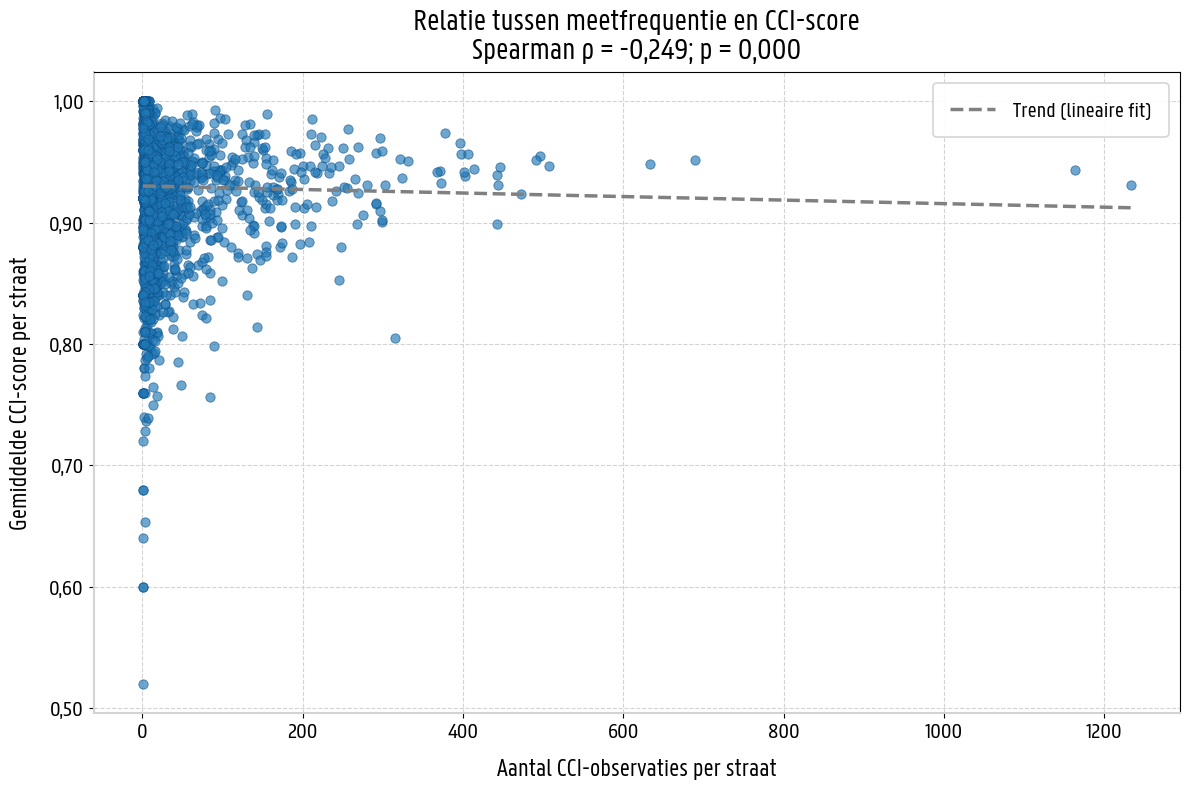

In [ ]:
# ============================================================
# 3.7.4 OPERATIONELE EVALUATIE: MEETFREQUENTIE-BIAS CCI
# ============================================================

OUTPUT_DIR = "fig_operational_evaluation"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# 1. CCI dataset voorbereiden
# ============================================================

CCI_full = CCI_clean.copy()

CCI_full["datum"] = pd.to_datetime(CCI_full["datum"], errors="coerce")

CCI_full["AverageCCI_std"] = pd.to_numeric(
    CCI_full["AverageCCI_std"],
    errors="coerce"
)

start_date = "2024-01-01"
end_date = "2026-03-31"

CCI_full = CCI_full[
    (CCI_full["datum"] >= start_date) &
    (CCI_full["datum"] <= end_date)
].copy()

# ============================================================
# 2. Aggregatie per straat (CCI)
# ============================================================

CCI_stability = (
    CCI_full
    .dropna(subset=["CCI_straten", "AverageCCI_std"])
    .groupby("CCI_straten")
    .agg(
        CCI_mean=("AverageCCI_std", "mean"),
        CCI_n_obs=("AverageCCI_std", "count")
    )
    .reset_index()
)

# ============================================================
# 3. Meetfrequentie-bias analyse
# ============================================================

cci_bias = CCI_stability.dropna(subset=["CCI_mean", "CCI_n_obs"]).copy()

sp_freq = spearmanr(
    cci_bias["CCI_n_obs"],
    cci_bias["CCI_mean"]
)

rho_text = f"{sp_freq.correlation:.3f}".replace(".", ",")
p_text = f"{sp_freq.pvalue:.3f}".replace(".", ",")
p_text_print = f"{sp_freq.pvalue:.4f}".replace(".", ",")

print("\n=== Meetfrequentie-bias CCI ===\n")
print(f"Analyseperiode: {start_date} t.e.m. {end_date}")
print(f"Aantal CCI-straten: {len(cci_bias)}")
print(
    f"Spearman rho observatiefrequentie vs gemiddelde CCI-score: "
    f"{rho_text}"
)
print(f"p-waarde: {p_text_print}")

# ============================================================
# 4. Scatterplot meetfrequentie vs CCI-score
# ============================================================

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    cci_bias["CCI_n_obs"],
    cci_bias["CCI_mean"],
    alpha=0.65,
    s=45,
    color="C0",
    edgecolor="#0b4f8a",
    linewidth=0.6
)

# =========================
# Trendline als visueel hulpmiddel
# =========================
z = np.polyfit(cci_bias["CCI_n_obs"], cci_bias["CCI_mean"], 1)
p = np.poly1d(z)
x_sorted = np.sort(cci_bias["CCI_n_obs"])

ax.plot(
    x_sorted,
    p(x_sorted),
    color="gray",
    linewidth=2.5,
    linestyle="--",
    label="Trend (lineaire fit)"
)

# =========================
# Assenlabels
# =========================
ax.set_xlabel(
    "Aantal CCI-observaties per straat",
    fontsize=18,
    fontweight="bold",
    labelpad=13
)

ax.set_ylabel(
    "Gemiddelde CCI-score per straat",
    fontsize=18,
    fontweight="bold",
    labelpad=13
)

# =========================
# Titel
# =========================
ax.set_title(
    "Relatie tussen meetfrequentie en CCI-score\n"
    f"Spearman ρ = {rho_text}; p = {p_text}",
    fontsize=22,
    fontweight="bold",
    pad=10
)

# =========================
# Punt -> komma op assen
# =========================
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.2f}".replace(".", ","))
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.0f}".replace(".", ","))
)

ax.tick_params(
    axis="both",
    labelsize=16
)

# =========================
# Gridlines
# =========================
ax.set_axisbelow(True)

ax.grid(
    axis="both",
    linestyle="dashed",
    color="lightgray",
    linewidth=0.8,
    zorder=0
)

# =========================
# Lichtgrijze assenlijnen
# =========================
ax.spines["left"].set_color("lightgray")
ax.spines["left"].set_linewidth(1.5)

ax.spines["bottom"].set_color("lightgray")
ax.spines["bottom"].set_linewidth(1.5)

# =========================
# Legende met kader
# =========================
legend = ax.legend(
    loc="upper right",
    fontsize=16,
    frameon=True,
    fancybox=True,
    framealpha=0.95,
    borderpad=0.8
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("lightgray")
legend.get_frame().set_linewidth(1.2)

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "cci_frequency_bias.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 5. Resultaten opslaan
# ============================================================

CCI_stability.to_csv(
    os.path.join(OUTPUT_DIR, "CCI_frequency_bias_per_street.csv"),
    index=False
)

# 3.7.5) Ruimtelijke Analyse


=== LISA-clusters ===
cluster
Niet significant    1187
High-High            168
Low-Low              125
Low-High              13
High-Low               9
Name: count, dtype: int64

=== Globale Moran's I voor CCI-score ===
Analyseperiode: 2024-01-01 t.e.m. 2026-03-31
Moran's I: 0.4311
p-waarde: 0.0010

=== RESULTAATTABEL ===
             cluster  n_cci_straten  cci_mean  n_nb_straten   nb_mean
0          High-High            168  0.962849             2  0.933981
1           High-Low              9  0.943069             0       NaN
2           Low-High             13  0.903257             0       NaN
3            Low-Low            125  0.858957             6  0.709639
4   Niet significant           1187  0.923223            51  0.853569
5  Volledige dekking           2399  0.927272            62  0.841300


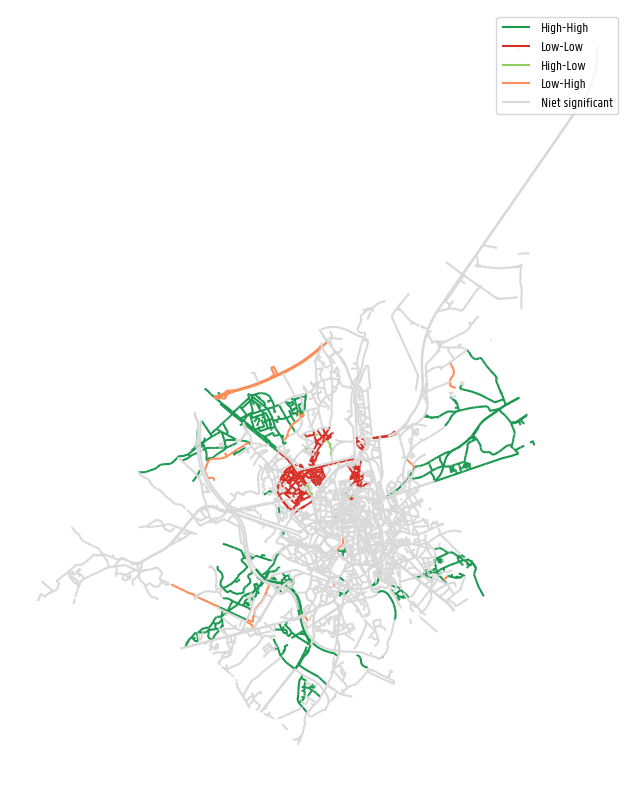

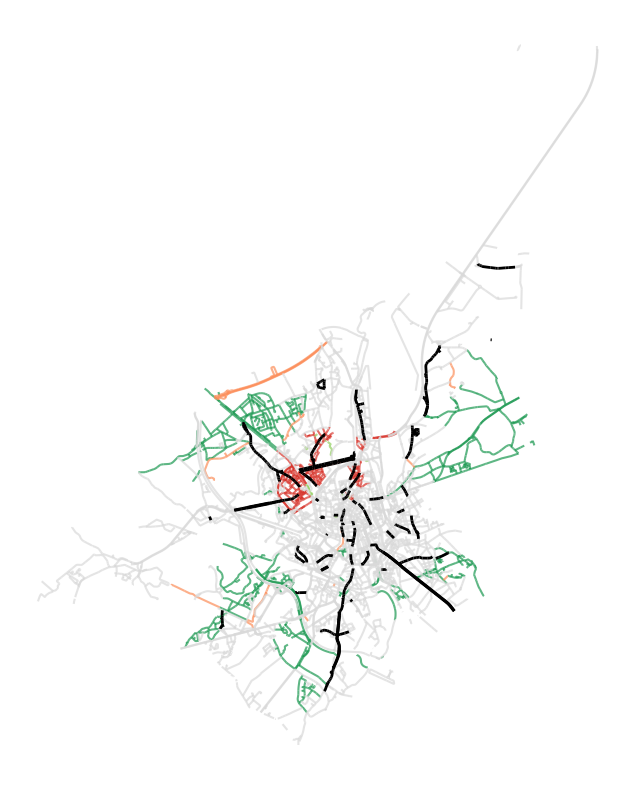

CCI shapefile opgeslagen
NB shapefile opgeslagen


In [ ]:
# ============================================================
# 3.7.5 RUIMTELIJKE ANALYSE (VOLLEDIG)
# ============================================================

from libpysal.weights import KNN
from esda.moran import Moran, Moran_Local

# ============================================================
# 1. Instellingen
# ============================================================

OUTPUT_DIR = "fig_spatial_cci_clusters"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MIN_OBS = 5
K_NEIGHBORS = 7
ALPHA = 0.01
RANDOM_SEED = 1234

start_date = "2024-01-01"
end_date = "2026-03-31"

# ============================================================
# 2. CCI voorbereiden en filteren op analyseperiode
# ============================================================

CCI_full = CCI_clean.copy()

CCI_full["datum"] = pd.to_datetime(CCI_full["datum"], errors="coerce")
CCI_full["AverageCCI_std"] = pd.to_numeric(
    CCI_full["AverageCCI_std"],
    errors="coerce"
)

CCI_full = CCI_full[
    (CCI_full["datum"] >= start_date) &
    (CCI_full["datum"] <= end_date)
].copy()

# ============================================================
# 3. CCI aggregeren per straat
# ============================================================

CCI_street = (
    CCI_full
    .dropna(subset=["CCI_straten", "AverageCCI_std"])
    .groupby("CCI_straten")
    .agg(
        cci_mean=("AverageCCI_std", "mean"),
        cci_n_obs=("AverageCCI_std", "count")
    )
    .reset_index()
)

CCI_street = CCI_street[CCI_street["cci_n_obs"] >= MIN_OBS]

# ============================================================
# 4. Geometrie koppelen
# ============================================================

matched_geo = matched_index.copy()

if not isinstance(matched_geo, gpd.GeoDataFrame):
    matched_geo = gpd.GeoDataFrame(
        matched_geo,
        geometry="geometry",
        crs="EPSG:31370"
    )

cci_gdf = CCI_street.merge(
    matched_geo[["CCI_straten", "geometry"]],
    on="CCI_straten",
    how="left"
)

cci_gdf = gpd.GeoDataFrame(cci_gdf, geometry="geometry")
cci_gdf = cci_gdf[cci_gdf.geometry.notna()].reset_index(drop=True)

# ============================================================
# 5. KNN gewichten
# ============================================================

centroids = cci_gdf.geometry.centroid
coords = np.column_stack([centroids.x, centroids.y])

w = KNN.from_array(coords, k=K_NEIGHBORS)
w.transform = "r"

# ============================================================
# 6. Moran + LISA
# ============================================================

np.random.seed(RANDOM_SEED)

y = cci_gdf["cci_mean"].values

moran = Moran(y, w, permutations=999)

np.random.seed(RANDOM_SEED)

lisa = Moran_Local(y, w, permutations=999)

cci_gdf["quadrant"] = lisa.q
cci_gdf["sig"] = lisa.p_sim < ALPHA

def label(row):
    if not row["sig"]:
        return "Niet significant"
    return {
        1: "High-High",
        2: "Low-High",
        3: "Low-Low",
        4: "High-Low"
    }.get(row["quadrant"], "Onbekend")

cci_gdf["cluster"] = cci_gdf.apply(label, axis=1)

print("\n=== LISA-clusters ===")
print(cci_gdf["cluster"].value_counts())

# ============================================================
# 7. NB voorbereiden en filteren op analyseperiode
# ============================================================

NB_full = NB_clean.copy()

NB_full["datum"] = pd.to_datetime(NB_full["datum"], errors="coerce")
NB_full["TOTAAL_std"] = pd.to_numeric(
    NB_full["TOTAAL_std"],
    errors="coerce"
)

NB_full = NB_full[
    (NB_full["datum"] >= start_date) &
    (NB_full["datum"] <= end_date)
].copy()

NB_street = (
    NB_full
    .dropna(subset=["NB_straten", "TOTAAL_std"])
    .groupby("NB_straten")
    .agg(nb_mean=("TOTAAL_std", "mean"))
    .reset_index()
)

# ============================================================
# 8. NB koppelen aan CCI-clusters
# ============================================================

nb_lookup = (
    matched_index
    .dropna(subset=["NB_straten", "CCI_straten"])
    .drop_duplicates("NB_straten")
    [["NB_straten", "CCI_straten"]]
)

NB_cluster = NB_street.merge(nb_lookup, on="NB_straten", how="left")

NB_cluster = NB_cluster.merge(
    cci_gdf[["CCI_straten", "cluster", "geometry"]],
    on="CCI_straten",
    how="left"
)

NB_cluster_gdf = gpd.GeoDataFrame(NB_cluster, geometry="geometry")
NB_cluster_gdf = NB_cluster_gdf[NB_cluster_gdf.geometry.notna()]

# ============================================================
# 9. Resultaattabel
# ============================================================

print("\n=== Globale Moran's I voor CCI-score ===")
print(f"Analyseperiode: {start_date} t.e.m. {end_date}")
print(f"Moran's I: {moran.I:.4f}")
print(f"p-waarde: {moran.p_sim:.4f}")

CCI_cluster_summary = (
    cci_gdf
    .groupby("cluster")
    .agg(
        n_cci_straten=("CCI_straten", "count"),
        cci_mean=("cci_mean", "mean")
    )
    .reset_index()
)

NB_cluster_summary = (
    NB_cluster_gdf
    .groupby("cluster")
    .agg(
        n_nb_straten=("NB_straten", "count"),
        nb_mean=("nb_mean", "mean")
    )
    .reset_index()
)

table = CCI_cluster_summary.merge(NB_cluster_summary, on="cluster", how="left")
table["n_nb_straten"] = table["n_nb_straten"].fillna(0).astype(int)

total = pd.DataFrame({
    "cluster": ["Volledige dekking"],
    "n_cci_straten": [CCI_full["CCI_straten"].nunique()],
    "cci_mean": [CCI_full["AverageCCI_std"].mean()],
    "n_nb_straten": [NB_full["NB_straten"].nunique()],
    "nb_mean": [NB_full["TOTAAL_std"].mean()]
})

table = pd.concat([table, total], ignore_index=True)

print("\n=== RESULTAATTABEL ===")
print(table)

# ============================================================
# 10. KAART 1: CCI LISA-clusters
# ============================================================

colors = {
    "High-High": "#1a9850",
    "Low-Low": "#d73027",
    "High-Low": "#91cf60",
    "Low-High": "#fc8d59",
    "Niet significant": "#d9d9d9"
}

fig, ax = plt.subplots(figsize=(10, 10))

for c, col in colors.items():
    cci_gdf[cci_gdf["cluster"] == c].plot(ax=ax, color=col, label=c)

ax.legend()
ax.axis("off")

plt.savefig(
    os.path.join(OUTPUT_DIR, "kaart_cci.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# 11. KAART 2: CCI LISA-clusters + NB-straten
# ============================================================

fig, ax = plt.subplots(figsize=(10, 10))

for c, col in colors.items():
    cci_gdf[cci_gdf["cluster"] == c].plot(ax=ax, color=col, alpha=0.7)

NB_cluster_gdf.plot(ax=ax, color="black", linewidth=2)

ax.axis("off")

plt.savefig(
    os.path.join(OUTPUT_DIR, "kaart_cci_nb.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# 12. Export shapefiles
# ============================================================

cci_export = cci_gdf.rename(columns={
    "CCI_straten": "straat",
    "cci_n_obs": "n_obs",
    "quadrant": "quad"
})

cci_export = cci_export[
    [
        "straat",
        "cci_mean",
        "n_obs",
        "quad",
        "sig",
        "cluster",
        "geometry"
    ]
].copy()

cci_export.to_file(os.path.join(OUTPUT_DIR, "cci_lisa_clusters.shp"))
print("CCI shapefile opgeslagen")


nb_export = NB_cluster_gdf.rename(columns={
    "NB_straten": "nb_str",
    "CCI_straten": "cci_str"
})

nb_export = nb_export[
    [
        "nb_str",
        "cci_str",
        "nb_mean",
        "cluster",
        "geometry"
    ]
].copy()

nb_export.to_file(os.path.join(OUTPUT_DIR, "nb_clusters.shp"))
print("NB shapefile opgeslagen")

In [67]:
print(len(CCI_street))
print(len(cci_gdf))
print(moran.I)
print(moran.p_sim)

1515
1502
0.4311332210298885
0.001


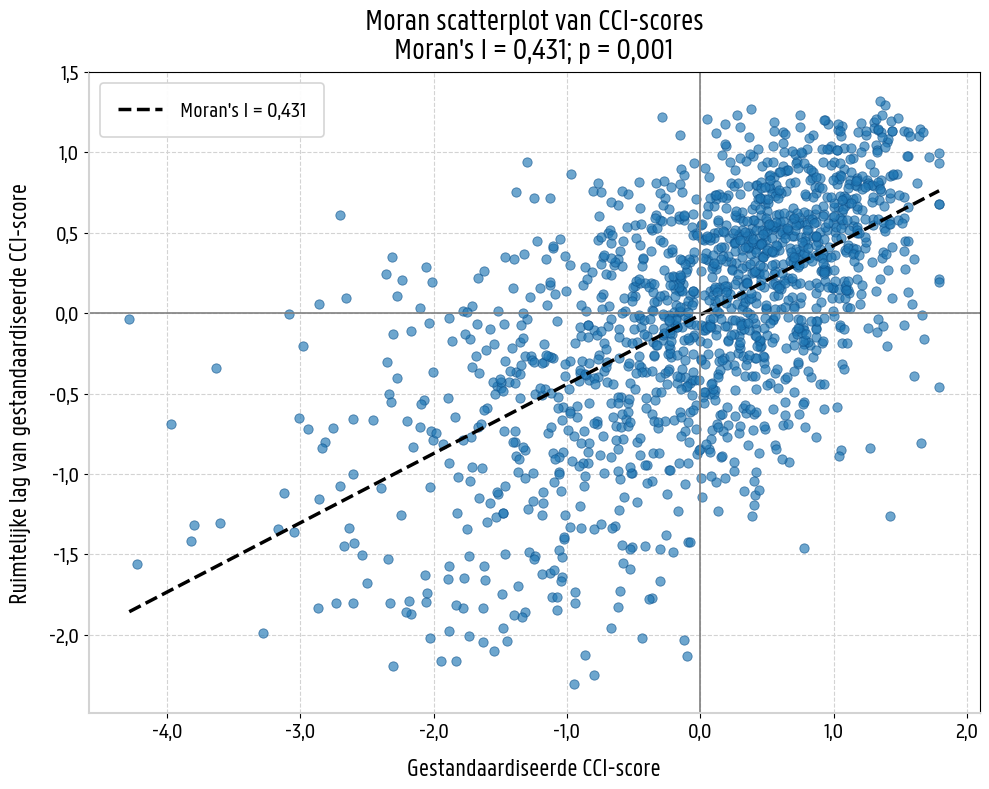

In [ ]:
# ============================================================
# EXTRA: MORAN'S I SCATTERPLOT
# ============================================================

from libpysal.weights.spatial_lag import lag_spatial

# ------------------------------------------------------------
# 1. Gestandaardiseerde CCI-score berekenen
# ------------------------------------------------------------

y = cci_gdf["cci_mean"].values

y_std = (y - y.mean()) / y.std(ddof=1)

# Ruimtelijke lag van gestandaardiseerde CCI-score
y_lag = lag_spatial(w, y_std)

# ------------------------------------------------------------
# 2. Moran scatterplot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    y_std,
    y_lag,
    alpha=0.65,
    s=45,
    color="C0",
    edgecolor="#0b4f8a",
    linewidth=0.6
)

# ------------------------------------------------------------
# 3. Regressielijn
# De helling komt overeen met Moran's I
# ------------------------------------------------------------

z = np.polyfit(y_std, y_lag, 1)
p = np.poly1d(z)

x_sorted = np.sort(y_std)

ax.plot(
    x_sorted,
    p(x_sorted),
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Moran's I = {moran.I:.3f}".replace(".", ",")
)

# ------------------------------------------------------------
# 4. Hulplijnen voor kwadranten
# ------------------------------------------------------------

ax.axhline(
    0,
    color="grey",
    linewidth=1.2
)

ax.axvline(
    0,
    color="grey",
    linewidth=1.2
)

# ------------------------------------------------------------
# 5. Labels en titel
# ------------------------------------------------------------

ax.set_xlabel(
    "Gestandaardiseerde CCI-score",
    fontsize=18,
    fontweight="bold",
    labelpad=13
)

ax.set_ylabel(
    "Ruimtelijke lag van gestandaardiseerde CCI-score",
    fontsize=18,
    fontweight="bold",
    labelpad=13
)

p_text = f"{moran.p_sim:.3f}".replace(".", ",")

ax.set_title(
    f"Moran scatterplot van CCI-scores\n"
    f"Moran's I = {str(round(moran.I, 3)).replace('.', ',')}; p = {p_text}",
    fontsize=22,
    fontweight="bold",
    pad=10
)

# ------------------------------------------------------------
# 6. Assen en opmaak
# ------------------------------------------------------------

ax.tick_params(axis="both", labelsize=16)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.1f}".replace(".", ","))
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.1f}".replace(".", ","))
)

ax.set_axisbelow(True)

ax.grid(
    axis="both",
    linestyle="dashed",
    color="lightgray",
    linewidth=0.8,
    zorder=0
)

ax.spines["left"].set_color("lightgray")
ax.spines["left"].set_linewidth(1.5)

ax.spines["bottom"].set_color("lightgray")
ax.spines["bottom"].set_linewidth(1.5)

legend = ax.legend(
    loc="upper left",
    fontsize=16,
    frameon=True,
    fancybox=True,
    framealpha=0.95,
    borderpad=0.8
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("lightgray")
legend.get_frame().set_linewidth(1.2)

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "moran_scatterplot_cci.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()